In [1]:
# ============================================================
# CELL 1 — SETUP + REPRODUCIBILITY CONTRACT
# CNS–PNS Additional Validation Analysis
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import sys
import json
import random
import hashlib
import platform
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt


# ============================================================
# 1. LOCK RANDOM SEEDS
# ============================================================

MASTER_SEED = 20260808

random.seed(MASTER_SEED)
np.random.seed(MASTER_SEED)
os.environ["PYTHONHASHSEED"] = str(MASTER_SEED)

# Pre-specified seeds for later robustness analysis.
# Do not change these after seeing results.
STABILITY_SEEDS = [
    1103,
    2207,
    3301,
    4409,
    5501,
    6607,
    7703,
    8807,
    9901,
    10103,
]


# ============================================================
# 2. CREATE SEPARATE VALIDATION WORKSPACE
# ============================================================

DRIVE_ROOT = Path("/content/drive/MyDrive")

PROJECT_ROOT = DRIVE_ROOT / "CNS_PNS_additional_validation"

PATHS = {
    "root": PROJECT_ROOT,
    "data": PROJECT_ROOT / "data",
    "checkpoints": PROJECT_ROOT / "checkpoints",
    "figures": PROJECT_ROOT / "figures",
    "tables": PROJECT_ROOT / "tables",
    "diagnostics": PROJECT_ROOT / "diagnostics",
    "logs": PROJECT_ROOT / "logs",
    "exports": PROJECT_ROOT / "manuscript_exports",
}

for path in PATHS.values():
    path.mkdir(parents=True, exist_ok=True)


# ============================================================
# 3. PRE-SPECIFY ANALYSIS PLAN
# ============================================================

ANALYSIS_CONTRACT = {

    "project":
        "CNS-PNS regeneration additional validation",

    "author":
        "Arjun Bhupatiraju",

    "master_seed":
        MASTER_SEED,

    "stability_seeds":
        STABILITY_SEEDS,

    "primary_question":
        (
            "Does the probability-defined PNS intermediate remain "
            "detectable when the transition model is constructed "
            "without CytoTRACE-directed priming?"
        ),

    "planned_analyses": [
        "Unprimed PNS transition model",
        "PNS reseeding/stability analysis",
        "Graph robustness analysis",
        "Endpoint-marker perturbation analysis",
        "Full-cell CNS validation",
        "CytoTRACE dispersion analysis",
        "Positive-control sensitivity analysis",
        "Bootstrap confidence intervals",
        "Locked cross-dataset comparison"
    ],

    "interpretation_rule":
        (
            "CytoTRACE may be considered independent supporting "
            "evidence only when CytoTRACE was not used to construct "
            "the corresponding transition model."
        ),

    "falsification_rule":
        (
            "If the PNS intermediate disappears or becomes unstable "
            "under an unprimed model or reasonable perturbations, "
            "that result will be reported rather than interpreted "
            "as support for biological plasticity."
        ),

    "result_selection":
        "All prespecified analyses will be reported regardless of outcome.",

    "original_notebook":
        "Must remain unchanged.",

    "no_result_chasing":
        True
}


# ============================================================
# 4. SAVE ANALYSIS CONTRACT
# ============================================================

contract_path = PATHS["logs"] / "analysis_contract.json"

contract_text = json.dumps(
    ANALYSIS_CONTRACT,
    indent=2,
    sort_keys=True
)

# Never silently overwrite the original contract.
if not contract_path.exists():
    contract_path.write_text(contract_text)
    contract_status = "NEW CONTRACT CREATED"
else:
    contract_status = "EXISTING CONTRACT PRESERVED"


# SHA-256 fingerprint
contract_hash = hashlib.sha256(
    contract_text.encode("utf-8")
).hexdigest()


# ============================================================
# 5. RECORD SOFTWARE ENVIRONMENT
# ============================================================

packages = {}

for package in [
    "scanpy",
    "anndata",
    "cellrank",
    "sklearn",
    "networkx",
    "seaborn"
]:
    try:
        module = __import__(package)
        packages[package] = getattr(
            module,
            "__version__",
            "installed"
        )
    except Exception:
        packages[package] = "NOT INSTALLED"


environment = {
    "timestamp_utc":
        datetime.now(timezone.utc).isoformat(),

    "python":
        sys.version,

    "platform":
        platform.platform(),

    "numpy":
        np.__version__,

    "pandas":
        pd.__version__,

    "scipy":
        scipy.__version__,

    "packages":
        packages
}

(PATHS["logs"] / "environment.json").write_text(
    json.dumps(environment, indent=2)
)


# ============================================================
# 6. SAVE CELL STATUS
# ============================================================

status = {
    "cell": 1,
    "name": "Setup and reproducibility contract",
    "status": "PASS",
    "timestamp_utc":
        datetime.now(timezone.utc).isoformat(),
    "analysis_contract_sha256":
        contract_hash
}

(PATHS["logs"] / "cell_01_status.json").write_text(
    json.dumps(status, indent=2)
)


# ============================================================
# 7. FINAL AUDIT OUTPUT
# ============================================================

print("=" * 70)
print("CNS–PNS ADDITIONAL VALIDATION")
print("CELL 1 — PASS")
print("=" * 70)

print(f"\nMaster seed: {MASTER_SEED}")
print(f"Stability seeds: {len(STABILITY_SEEDS)} locked")

print(f"\nWorkspace:")
print(PROJECT_ROOT)

print(f"\nAnalysis contract:")
print(contract_status)

print(f"\nContract SHA-256:")
print(contract_hash)

print("\nSoftware:")
print(f"Python:  {platform.python_version()}")
print(f"NumPy:   {np.__version__}")
print(f"Pandas:  {pd.__version__}")
print(f"SciPy:   {scipy.__version__}")

for package, version in packages.items():
    print(f"{package:10s}: {version}")

print("\n" + "=" * 70)
print("ORIGINAL ANALYSIS: UNTOUCHED")
print("NEW VALIDATION WORKSPACE: READY")
print("ANALYSIS QUESTIONS: PRE-SPECIFIED")
print("RANDOM SEEDS: LOCKED")
print("NO BIOLOGICAL RESULTS GENERATED YET")
print("=" * 70)

Mounted at /content/drive
CNS–PNS ADDITIONAL VALIDATION
CELL 1 — PASS

Master seed: 20260808
Stability seeds: 10 locked

Workspace:
/content/drive/MyDrive/CNS_PNS_additional_validation

Analysis contract:
NEW CONTRACT CREATED

Contract SHA-256:
e0a7d5d1b0212c330908c4a82e6260d43742ef05ce8ff83dac3d7759c4634779

Software:
Python:  3.12.13
NumPy:   2.0.2
Pandas:  2.2.2
SciPy:   1.16.3
scanpy    : NOT INSTALLED
anndata   : NOT INSTALLED
cellrank  : NOT INSTALLED
sklearn   : 1.6.1
networkx  : 3.6.1
seaborn   : 0.13.2

ORIGINAL ANALYSIS: UNTOUCHED
NEW VALIDATION WORKSPACE: READY
ANALYSIS QUESTIONS: PRE-SPECIFIED
RANDOM SEEDS: LOCKED
NO BIOLOGICAL RESULTS GENERATED YET


In [2]:
# ============================================================
# CELL 2 — DISCOVER + AUDIT ORIGINAL ANALYSIS ARTIFACTS
# ============================================================
#
# PURPOSE
# -------
# Locate the original PNS/CNS analysis notebooks, AnnData objects,
# matrices, metadata, CellRank outputs, CytoTRACE outputs, and
# checkpoints that already exist in Google Drive.
#
# THIS CELL:
#   - does NOT modify original files
#   - does NOT run new biological analyses
#   - does NOT install packages
#   - does NOT select files based on desired results
#
# The output determines whether Cell 3 can reload existing objects
# or must reproducibly reconstruct them from original data.
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import pandas as pd
import json
import hashlib
import os

# ------------------------------------------------------------
# 1. Verify Cell 1 workspace
# ------------------------------------------------------------

assert "PROJECT_ROOT" in globals(), (
    "PROJECT_ROOT missing. Run Cell 1 first."
)

assert PROJECT_ROOT.exists(), (
    f"Validation workspace does not exist: {PROJECT_ROOT}"
)

print("=" * 72)
print("CELL 2 — ORIGINAL ANALYSIS ARTIFACT DISCOVERY")
print("=" * 72)
print("\nValidation workspace verified:")
print(PROJECT_ROOT)


# ------------------------------------------------------------
# 2. File extensions worth auditing
# ------------------------------------------------------------

RELEVANT_EXTENSIONS = {
    ".ipynb",   # notebooks
    ".h5ad",    # AnnData
    ".h5",      # HDF5
    ".hdf5",
    ".pkl",
    ".pickle",
    ".joblib",
    ".npz",
    ".npy",
    ".mtx",
    ".csv",
    ".tsv",
    ".txt",
    ".json",
    ".parquet",
    ".feather",
    ".loom",
    ".gz",
}


# ------------------------------------------------------------
# 3. Keywords associated with THIS project
# ------------------------------------------------------------

KEYWORDS = [
    "cns",
    "pns",
    "schwann",
    "microglia",
    "cellrank",
    "cytotrace",
    "regeneration",
    "injury",
    "gse198582",
    "gse172167",
    "fate",
    "trajectory",
    "transition",
    "validation",
    "adata",
    "anndata",
]


# ------------------------------------------------------------
# 4. Directories to ignore
# ------------------------------------------------------------

# We must not mistake the NEW validation outputs for original data.

IGNORE_ROOTS = [
    PROJECT_ROOT.resolve()
]


def is_ignored(path):
    """Return True if path belongs to new validation workspace."""
    try:
        resolved = path.resolve()
        return any(
            root == resolved or root in resolved.parents
            for root in IGNORE_ROOTS
        )
    except Exception:
        return False


# ------------------------------------------------------------
# 5. Safe file hash
# ------------------------------------------------------------

def sha256_file(path, chunk_size=1024 * 1024):
    """
    Compute SHA-256 without loading whole file into RAM.
    """
    h = hashlib.sha256()

    try:
        with open(path, "rb") as f:
            while True:
                chunk = f.read(chunk_size)
                if not chunk:
                    break
                h.update(chunk)

        return h.hexdigest()

    except Exception as exc:
        return f"ERROR:{type(exc).__name__}"


# ------------------------------------------------------------
# 6. Search Google Drive
# ------------------------------------------------------------

DRIVE_SEARCH_ROOT = Path("/content/drive/MyDrive")

print("\nSearching Google Drive for relevant original artifacts...")
print("This can take a little while if Drive contains many files.\n")

records = []

files_examined = 0

for root, dirs, files in os.walk(DRIVE_SEARCH_ROOT):

    root_path = Path(root)

    # Prevent traversal into our new validation directory
    dirs[:] = [
        d for d in dirs
        if not is_ignored(root_path / d)
    ]

    for filename in files:

        files_examined += 1

        path = root_path / filename

        if is_ignored(path):
            continue

        suffix = path.suffix.lower()
        filename_lower = filename.lower()
        path_lower = str(path).lower()

        keyword_hits = [
            word for word in KEYWORDS
            if word in filename_lower or word in path_lower
        ]

        # Include:
        #  1. biologically/project-relevant named files
        #  2. notebooks
        #  3. AnnData/HDF/loom objects
        #
        # Avoid dumping every random CSV in Drive.

        high_value_extension = suffix in {
            ".ipynb",
            ".h5ad",
            ".h5",
            ".hdf5",
            ".loom",
            ".pkl",
            ".pickle",
            ".npz",
            ".parquet",
        }

        if not keyword_hits and not high_value_extension:
            continue

        try:
            stat = path.stat()

            size_mb = stat.st_size / (1024 ** 2)

            modified = datetime.fromtimestamp(
                stat.st_mtime,
                tz=timezone.utc
            ).isoformat()

        except Exception:
            size_mb = None
            modified = None

        records.append({
            "path": str(path),
            "filename": filename,
            "extension": suffix,
            "size_mb": size_mb,
            "modified_utc": modified,
            "keyword_hits": ",".join(sorted(set(keyword_hits))),
        })


# ------------------------------------------------------------
# 7. Build inventory
# ------------------------------------------------------------

inventory = pd.DataFrame(records)

print(f"Files examined: {files_examined:,}")
print(f"Potentially relevant artifacts: {len(inventory):,}")


if len(inventory) == 0:

    print("\nNO CANDIDATE FILES FOUND.")

    print(
        "\nThis does not mean the original data are lost. "
        "They may simply have generic filenames or exist only "
        "inside the original notebook."
    )

else:

    inventory["size_mb"] = pd.to_numeric(
        inventory["size_mb"],
        errors="coerce"
    )

    # Prioritize likely reusable objects

    priority_map = {
        ".h5ad": 1,
        ".loom": 2,
        ".h5": 3,
        ".hdf5": 3,
        ".pkl": 4,
        ".pickle": 4,
        ".npz": 5,
        ".parquet": 6,
        ".ipynb": 7,
        ".csv": 8,
        ".tsv": 8,
        ".txt": 9,
        ".json": 9,
    }

    inventory["priority"] = (
        inventory["extension"]
        .map(priority_map)
        .fillna(99)
    )

    inventory = inventory.sort_values(
        ["priority", "size_mb"],
        ascending=[True, False]
    ).reset_index(drop=True)


# ------------------------------------------------------------
# 8. Print high-value candidates
# ------------------------------------------------------------

if len(inventory):

    print("\n" + "=" * 72)
    print("TOP CANDIDATE FILES")
    print("=" * 72)

    display_columns = [
        "filename",
        "extension",
        "size_mb",
        "keyword_hits",
        "path"
    ]

    with pd.option_context(
        "display.max_rows", 100,
        "display.max_colwidth", 120
    ):
        display(
            inventory[display_columns].head(100)
        )


# ------------------------------------------------------------
# 9. Specifically identify notebooks
# ------------------------------------------------------------

if len(inventory):

    notebooks = inventory[
        inventory["extension"] == ".ipynb"
    ].copy()

else:

    notebooks = pd.DataFrame()


print("\n" + "=" * 72)
print("NOTEBOOK CANDIDATES")
print("=" * 72)

if len(notebooks):

    for i, row in notebooks.iterrows():

        print(
            f"\n[{i}] {row['filename']}"
            f"\n    {row['path']}"
            f"\n    Size: {row['size_mb']:.2f} MB"
            f"\n    Keywords: {row['keyword_hits']}"
        )

else:

    print("No notebooks found by the current search.")


# ------------------------------------------------------------
# 10. Specifically identify reusable analysis objects
# ------------------------------------------------------------

OBJECT_EXTENSIONS = {
    ".h5ad",
    ".loom",
    ".h5",
    ".hdf5",
    ".pkl",
    ".pickle",
    ".npz",
    ".parquet",
}

if len(inventory):

    objects = inventory[
        inventory["extension"].isin(OBJECT_EXTENSIONS)
    ].copy()

else:

    objects = pd.DataFrame()


print("\n" + "=" * 72)
print("REUSABLE OBJECT CANDIDATES")
print("=" * 72)

if len(objects):

    for i, row in objects.head(50).iterrows():

        print(
            f"\n[{i}] {row['filename']}"
            f"\n    Type: {row['extension']}"
            f"\n    Size: {row['size_mb']:.2f} MB"
            f"\n    {row['path']}"
        )

else:

    print("No obvious serialized analysis objects found.")


# ------------------------------------------------------------
# 11. Hash the most important manageable files
# ------------------------------------------------------------

# Hash notebooks and reusable objects <= 2 GB.
# This provides provenance without trying to read huge datasets
# into memory.

hash_records = []

if len(inventory):

    hash_candidates = inventory[
        (
            inventory["extension"].isin(
                OBJECT_EXTENSIONS | {".ipynb"}
            )
        )
        &
        (
            inventory["size_mb"].fillna(float("inf")) <= 2048
        )
    ].copy()

    print(
        f"\nComputing SHA-256 for "
        f"{len(hash_candidates)} candidate files..."
    )

    for _, row in hash_candidates.iterrows():

        path = Path(row["path"])

        digest = sha256_file(path)

        hash_records.append({
            "path": str(path),
            "filename": path.name,
            "size_mb": row["size_mb"],
            "sha256": digest,
        })


hash_df = pd.DataFrame(hash_records)


# ------------------------------------------------------------
# 12. Persist the audit
# ------------------------------------------------------------

inventory_path = PATHS["tables"] / "original_artifact_inventory.csv"
hash_path = PATHS["tables"] / "original_artifact_hashes.csv"

inventory.to_csv(
    inventory_path,
    index=False
)

hash_df.to_csv(
    hash_path,
    index=False
)


# ------------------------------------------------------------
# 13. Cell status
# ------------------------------------------------------------

cell2_status = {
    "cell": 2,
    "name": "Original analysis artifact discovery",
    "status": "PASS",
    "timestamp_utc":
        datetime.now(timezone.utc).isoformat(),

    "files_examined":
        int(files_examined),

    "candidate_artifacts":
        int(len(inventory)),

    "candidate_notebooks":
        int(len(notebooks)),

    "candidate_reusable_objects":
        int(len(objects)),

    "files_hashed":
        int(len(hash_df)),

    "original_files_modified":
        False,
}

(PATHS["logs"] / "cell_02_status.json").write_text(
    json.dumps(cell2_status, indent=2)
)


# ------------------------------------------------------------
# 14. Final output
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("CELL 2 COMPLETE — PASS")
print("=" * 72)

print(f"Files examined:              {files_examined:,}")
print(f"Candidate artifacts:         {len(inventory):,}")
print(f"Candidate notebooks:         {len(notebooks):,}")
print(f"Reusable object candidates:  {len(objects):,}")
print(f"Files hashed:                {len(hash_df):,}")

print("\nAudit saved to:")
print(inventory_path)
print(hash_path)

print("\nORIGINAL FILES MODIFIED: NO")
print("NEW BIOLOGICAL ANALYSIS PERFORMED: NO")

print("=" * 72)

CELL 2 — ORIGINAL ANALYSIS ARTIFACT DISCOVERY

Validation workspace verified:
/content/drive/MyDrive/CNS_PNS_additional_validation

Searching Google Drive for relevant original artifacts...
This can take a little while if Drive contains many files.

Files examined: 151
Potentially relevant artifacts: 16

TOP CANDIDATE FILES


,filename,extension,size_mb,keyword_hits,path
0,cns_injury_preprocessed.h5ad,.h5ad,1224.015173,"cns,injury",/content/drive/MyDrive/cns_injury_preprocessed.h5ad
1,cns_injury.h5ad,.h5ad,624.012515,"cns,injury",/content/drive/MyDrive/cns_injury.h5ad
2,pns_regenerative_fork_final.h5ad,.h5ad,171.365324,pns,/content/drive/MyDrive/pns_regenerative_fork_final.h5ad
3,pns_cytotrace_cellrank_final.h5ad,.h5ad,170.958223,"cellrank,cytotrace,pns",/content/drive/MyDrive/pns_cytotrace_cellrank_final.h5ad
4,cns_cytotrace_cellrank_final.h5ad,.h5ad,67.999192,"cellrank,cns,cytotrace",/content/drive/MyDrive/cns_cytotrace_cellrank_final.h5ad
5,pns_regeneration_compartment_cellrank.h5ad,.h5ad,8.198151,"cellrank,pns,regeneration",/content/drive/MyDrive/pns_regeneration_compartment_cellrank.h5ad
6,cns_master_switches.csv,.csv,6.087067,cns,/content/drive/MyDrive/cns_master_switches.csv
7,pns_master_switches.csv,.csv,5.924932,pns,/content/drive/MyDrive/pns_master_switches.csv
8,pns_regeneration_favorable_genes.csv,.csv,0.190674,"pns,regeneration",/content/drive/MyDrive/pns_regeneration_favorable_genes.csv
9,pns_selected_regeneration_compartment_cells.csv,.csv,0.025364,"pns,regeneration",/content/drive/MyDrive/pns_selected_regeneration_compartment_cells.csv



NOTEBOOK CANDIDATES
No notebooks found by the current search.

REUSABLE OBJECT CANDIDATES

[0] cns_injury_preprocessed.h5ad
    Type: .h5ad
    Size: 1224.02 MB
    /content/drive/MyDrive/cns_injury_preprocessed.h5ad

[1] cns_injury.h5ad
    Type: .h5ad
    Size: 624.01 MB
    /content/drive/MyDrive/cns_injury.h5ad

[2] pns_regenerative_fork_final.h5ad
    Type: .h5ad
    Size: 171.37 MB
    /content/drive/MyDrive/pns_regenerative_fork_final.h5ad

[3] pns_cytotrace_cellrank_final.h5ad
    Type: .h5ad
    Size: 170.96 MB
    /content/drive/MyDrive/pns_cytotrace_cellrank_final.h5ad

[4] cns_cytotrace_cellrank_final.h5ad
    Type: .h5ad
    Size: 68.00 MB
    /content/drive/MyDrive/cns_cytotrace_cellrank_final.h5ad

[5] pns_regeneration_compartment_cellrank.h5ad
    Type: .h5ad
    Size: 8.20 MB
    /content/drive/MyDrive/pns_regeneration_compartment_cellrank.h5ad

Computing SHA-256 for 6 candidate files...

CELL 2 COMPLETE — PASS
Files examined:              151
Candidate artifacts:    

In [3]:
# ============================================================
# CELL 3 — READ-ONLY STRUCTURAL AUDIT OF SAVED .H5AD OBJECTS
# ============================================================
#
# PURPOSE
# -------
# Inspect the actual saved PNS/CNS AnnData objects to determine:
#
#   1. exact cell × gene dimensions
#   2. available metadata columns
#   3. CytoTRACE-related fields
#   4. CellRank/fate-probability-related fields
#   5. embeddings
#   6. graph matrices
#   7. layers
#   8. raw-count availability
#   9. overlap between saved PNS objects
#
# IMPORTANT:
#   - All .h5ad files opened backed="r"
#   - Original objects are NEVER modified
#   - No new biological analysis is performed
# ============================================================


# ------------------------------------------------------------
# 0. Install ONLY the reader required for this audit
# ------------------------------------------------------------

!pip -q install "anndata>=0.10,<0.13" h5py

import anndata as ad
import h5py
import numpy as np
import pandas as pd
import json
from pathlib import Path
from datetime import datetime, timezone


print("=" * 76)
print("CELL 3 — SAVED OBJECT STRUCTURAL AUDIT")
print("=" * 76)

print(f"\nAnnData version: {ad.__version__}")
print(f"h5py version:    {h5py.__version__}")


# ------------------------------------------------------------
# 1. Exact objects discovered in Cell 2
# ------------------------------------------------------------

OBJECT_PATHS = {

    "PNS_FORK_FINAL":
        Path("/content/drive/MyDrive/pns_regenerative_fork_final.h5ad"),

    "PNS_CYTOTRACE_CELLRANK_FINAL":
        Path("/content/drive/MyDrive/pns_cytotrace_cellrank_final.h5ad"),

    "PNS_COMPARTMENT_CELLRANK":
        Path("/content/drive/MyDrive/pns_regeneration_compartment_cellrank.h5ad"),

    "CNS_CYTOTRACE_CELLRANK_FINAL":
        Path("/content/drive/MyDrive/cns_cytotrace_cellrank_final.h5ad"),

    "CNS_PREPROCESSED":
        Path("/content/drive/MyDrive/cns_injury_preprocessed.h5ad"),

    "CNS_RAW_OR_EARLY":
        Path("/content/drive/MyDrive/cns_injury.h5ad"),
}


# ------------------------------------------------------------
# 2. Confirm files have not disappeared
# ------------------------------------------------------------

print("\nObject availability:")

for name, path in OBJECT_PATHS.items():

    exists = path.exists()

    size_mb = (
        path.stat().st_size / (1024 ** 2)
        if exists else np.nan
    )

    print(
        f"{name:32s} "
        f"{'FOUND' if exists else 'MISSING':8s} "
        f"{size_mb:10.2f} MB"
    )

assert all(path.exists() for path in OBJECT_PATHS.values()), (
    "One or more expected objects are missing."
)


# ------------------------------------------------------------
# 3. Search terms for important analysis fields
# ------------------------------------------------------------

SEARCH_TERMS = [
    "cytotrace",
    "cellrank",
    "fate",
    "prob",
    "absorp",
    "entropy",
    "terminal",
    "initial",
    "root",
    "transition",
    "regener",
    "repair",
    "myelin",
    "schwann",
    "microglia",
    "cluster",
    "lineage",
    "state",
    "pseudotime",
]


def relevant_names(names):
    """
    Return fields whose names suggest relevance to the
    original trajectory/fate/plasticity analysis.
    """
    output = []

    for name in map(str, names):

        lower = name.lower()

        if any(term in lower for term in SEARCH_TERMS):
            output.append(name)

    return sorted(output)


# ------------------------------------------------------------
# 4. Safe structural auditor
# ------------------------------------------------------------

def audit_anndata(label, path):

    print("\n" + "=" * 76)
    print(label)
    print("=" * 76)

    # READ-ONLY backed mode
    obj = ad.read_h5ad(path, backed="r")

    report = {
        "label": label,
        "path": str(path),
        "n_obs": int(obj.n_obs),
        "n_vars": int(obj.n_vars),
        "obs_columns": list(map(str, obj.obs.columns)),
        "var_columns": list(map(str, obj.var.columns)),
        "obsm_keys": list(map(str, obj.obsm.keys())),
        "varm_keys": list(map(str, obj.varm.keys())),
        "obsp_keys": list(map(str, obj.obsp.keys())),
        "layers": list(map(str, obj.layers.keys())),
        "uns_keys": list(map(str, obj.uns.keys())),
        "has_raw": obj.raw is not None,
        "relevant_obs": relevant_names(obj.obs.columns),
        "relevant_obsm": relevant_names(obj.obsm.keys()),
        "relevant_obsp": relevant_names(obj.obsp.keys()),
        "relevant_uns": relevant_names(obj.uns.keys()),
        "relevant_layers": relevant_names(obj.layers.keys()),
    }

    print(f"Shape:          {obj.n_obs:,} cells × {obj.n_vars:,} genes")
    print(f"Raw available:  {obj.raw is not None}")

    if obj.raw is not None:
        try:
            print(
                f"Raw shape:      "
                f"{obj.raw.n_obs:,} cells × "
                f"{obj.raw.n_vars:,} genes"
            )

            report["raw_n_obs"] = int(obj.raw.n_obs)
            report["raw_n_vars"] = int(obj.raw.n_vars)

        except Exception as exc:
            print(f"Raw shape:      unable to inspect ({exc})")

    print(f"\nobs columns:    {len(obj.obs.columns)}")
    print(f"var columns:    {len(obj.var.columns)}")
    print(f"obsm keys:      {list(obj.obsm.keys())}")
    print(f"obsp keys:      {list(obj.obsp.keys())}")
    print(f"layers:         {list(obj.layers.keys())}")

    print("\nPotentially important obs fields:")
    if report["relevant_obs"]:
        for x in report["relevant_obs"]:
            print("   ", x)
    else:
        print("    NONE DETECTED")

    print("\nPotentially important obsm fields:")
    if report["relevant_obsm"]:
        for x in report["relevant_obsm"]:
            print("   ", x)
    else:
        print("    NONE DETECTED")

    print("\nPotentially important obsp fields:")
    if report["relevant_obsp"]:
        for x in report["relevant_obsp"]:
            print("   ", x)
    else:
        print("    NONE DETECTED")

    print("\nPotentially important uns fields:")
    if report["relevant_uns"]:
        for x in report["relevant_uns"]:
            print("   ", x)
    else:
        print("    NONE DETECTED")

    # --------------------------------------------------------
    # Examine useful obs columns WITHOUT altering object
    # --------------------------------------------------------

    obs_summaries = {}

    for col in report["relevant_obs"]:

        try:
            series = obj.obs[col]

            summary = {
                "dtype": str(series.dtype),
                "n_missing": int(series.isna().sum()),
                "n_unique": int(series.nunique(dropna=True)),
            }

            if pd.api.types.is_numeric_dtype(series):

                vals = pd.to_numeric(series, errors="coerce")

                summary.update({
                    "min": (
                        float(vals.min())
                        if vals.notna().any() else None
                    ),
                    "median": (
                        float(vals.median())
                        if vals.notna().any() else None
                    ),
                    "mean": (
                        float(vals.mean())
                        if vals.notna().any() else None
                    ),
                    "max": (
                        float(vals.max())
                        if vals.notna().any() else None
                    ),
                })

            elif series.nunique(dropna=True) <= 30:

                counts = (
                    series
                    .astype(str)
                    .value_counts(dropna=False)
                    .head(30)
                )

                summary["value_counts"] = {
                    str(k): int(v)
                    for k, v in counts.items()
                }

            obs_summaries[col] = summary

        except Exception as exc:

            obs_summaries[col] = {
                "error": repr(exc)
            }

    report["obs_summaries"] = obs_summaries

    print("\nRelevant obs summaries:")

    for col, summary in obs_summaries.items():

        print(f"\n  [{col}]")

        print(
            f"    dtype={summary.get('dtype')} | "
            f"unique={summary.get('n_unique')} | "
            f"missing={summary.get('n_missing')}"
        )

        if "mean" in summary:

            print(
                "    "
                f"min={summary['min']:.6g} | "
                f"median={summary['median']:.6g} | "
                f"mean={summary['mean']:.6g} | "
                f"max={summary['max']:.6g}"
            )

        if "value_counts" in summary:

            print("    counts:", summary["value_counts"])

    # Copy identifiers only into memory so we can later
    # compare objects without keeping the HDF5 file open.

    obs_names = pd.Index(
        obj.obs_names.astype(str).to_numpy(copy=True)
    )

    var_names = pd.Index(
        obj.var_names.astype(str).to_numpy(copy=True)
    )

    # Explicitly close backed HDF5 handle
    if getattr(obj, "file", None) is not None:
        obj.file.close()

    return report, obs_names, var_names


# ------------------------------------------------------------
# 5. Audit all six saved objects
# ------------------------------------------------------------

REPORTS = {}
OBS_IDS = {}
VAR_IDS = {}

for label, path in OBJECT_PATHS.items():

    try:

        report, obs_ids, var_ids = audit_anndata(
            label,
            path
        )

        REPORTS[label] = report
        OBS_IDS[label] = obs_ids
        VAR_IDS[label] = var_ids

    except Exception as exc:

        print("\n" + "!" * 76)
        print(f"FAILED TO READ: {label}")
        print(repr(exc))
        print("!" * 76)

        REPORTS[label] = {
            "label": label,
            "path": str(path),
            "ERROR": repr(exc),
        }


# ------------------------------------------------------------
# 6. Pairwise PNS cell-overlap audit
# ------------------------------------------------------------

PNS_OBJECTS = [
    "PNS_FORK_FINAL",
    "PNS_CYTOTRACE_CELLRANK_FINAL",
    "PNS_COMPARTMENT_CELLRANK",
]

overlap_records = []

print("\n" + "=" * 76)
print("PNS CELL-ID OVERLAP")
print("=" * 76)

for i in range(len(PNS_OBJECTS)):

    for j in range(i + 1, len(PNS_OBJECTS)):

        a = PNS_OBJECTS[i]
        b = PNS_OBJECTS[j]

        if a not in OBS_IDS or b not in OBS_IDS:
            continue

        A = set(OBS_IDS[a])
        B = set(OBS_IDS[b])

        shared = A.intersection(B)

        record = {
            "object_A": a,
            "object_B": b,
            "n_A": len(A),
            "n_B": len(B),
            "n_shared": len(shared),
            "fraction_A_in_B": (
                len(shared) / len(A)
                if len(A) else np.nan
            ),
            "fraction_B_in_A": (
                len(shared) / len(B)
                if len(B) else np.nan
            ),
        }

        overlap_records.append(record)

        print(
            f"\n{a}"
            f"\nvs {b}"
            f"\n  A cells: {len(A):,}"
            f"\n  B cells: {len(B):,}"
            f"\n  Shared:  {len(shared):,}"
            f"\n  A→B:     {record['fraction_A_in_B']:.3%}"
            f"\n  B→A:     {record['fraction_B_in_A']:.3%}"
        )

overlap_df = pd.DataFrame(overlap_records)


# ------------------------------------------------------------
# 7. Compare gene universes
# ------------------------------------------------------------

gene_overlap_records = []

print("\n" + "=" * 76)
print("GENE-UNIVERSE OVERLAP")
print("=" * 76)

COMPARE_PAIRS = [
    ("PNS_FORK_FINAL", "PNS_CYTOTRACE_CELLRANK_FINAL"),
    ("PNS_FORK_FINAL", "PNS_COMPARTMENT_CELLRANK"),
    ("PNS_CYTOTRACE_CELLRANK_FINAL", "CNS_CYTOTRACE_CELLRANK_FINAL"),
]

for a, b in COMPARE_PAIRS:

    if a not in VAR_IDS or b not in VAR_IDS:
        continue

    A = set(VAR_IDS[a])
    B = set(VAR_IDS[b])

    shared = A.intersection(B)

    gene_overlap_records.append({
        "object_A": a,
        "object_B": b,
        "genes_A": len(A),
        "genes_B": len(B),
        "shared_genes": len(shared),
    })

    print(
        f"\n{a}"
        f"\nvs {b}"
        f"\n  genes A: {len(A):,}"
        f"\n  genes B: {len(B):,}"
        f"\n  shared:  {len(shared):,}"
    )

gene_overlap_df = pd.DataFrame(gene_overlap_records)


# ------------------------------------------------------------
# 8. Save audit outputs
# ------------------------------------------------------------

audit_json_path = (
    PATHS["diagnostics"] /
    "cell03_saved_object_structural_audit.json"
)

audit_json_path.write_text(
    json.dumps(
        REPORTS,
        indent=2,
        default=str
    )
)

overlap_df.to_csv(
    PATHS["tables"] /
    "cell03_pns_cell_overlap.csv",
    index=False
)

gene_overlap_df.to_csv(
    PATHS["tables"] /
    "cell03_gene_overlap.csv",
    index=False
)


# ------------------------------------------------------------
# 9. Compact master table
# ------------------------------------------------------------

master_rows = []

for label, report in REPORTS.items():

    if "ERROR" in report:

        master_rows.append({
            "object": label,
            "status": "READ_ERROR",
            "cells": np.nan,
            "genes": np.nan,
            "raw": np.nan,
            "obs_fields": np.nan,
            "obsm_fields": np.nan,
            "obsp_fields": np.nan,
        })

    else:

        master_rows.append({
            "object": label,
            "status": "READ_OK",
            "cells": report["n_obs"],
            "genes": report["n_vars"],
            "raw": report["has_raw"],
            "obs_fields": len(report["obs_columns"]),
            "obsm_fields": len(report["obsm_keys"]),
            "obsp_fields": len(report["obsp_keys"]),
        })

master_table = pd.DataFrame(master_rows)

master_table.to_csv(
    PATHS["tables"] /
    "cell03_object_summary.csv",
    index=False
)


print("\n" + "=" * 76)
print("MASTER OBJECT SUMMARY")
print("=" * 76)

display(master_table)


# ------------------------------------------------------------
# 10. Determine audit status
# ------------------------------------------------------------

n_success = sum(
    "ERROR" not in report
    for report in REPORTS.values()
)

n_failed = len(REPORTS) - n_success

CELL3_STATUS = (
    "PASS"
    if n_failed == 0
    else "PASS_WITH_READ_ERRORS"
)


cell3_status = {
    "cell": 3,
    "name": "Saved object structural audit",
    "status": CELL3_STATUS,
    "timestamp_utc":
        datetime.now(timezone.utc).isoformat(),
    "objects_requested": len(OBJECT_PATHS),
    "objects_read_successfully": n_success,
    "objects_failed": n_failed,
    "original_files_modified": False,
    "new_biological_analysis": False,
}


(
    PATHS["logs"] /
    "cell_03_status.json"
).write_text(
    json.dumps(cell3_status, indent=2)
)


# ------------------------------------------------------------
# 11. Final checkpoint
# ------------------------------------------------------------

print("\n" + "=" * 76)
print(f"CELL 3 COMPLETE — {CELL3_STATUS}")
print("=" * 76)

print(f"Objects read successfully: {n_success}/{len(OBJECT_PATHS)}")
print(f"Objects with read errors:  {n_failed}")

print("\nOriginal .h5ad files modified: NO")
print("New biological analysis performed: NO")

print("\nSaved:")
print(
    PATHS["diagnostics"] /
    "cell03_saved_object_structural_audit.json"
)
print(
    PATHS["tables"] /
    "cell03_object_summary.csv"
)
print(
    PATHS["tables"] /
    "cell03_pns_cell_overlap.csv"
)
print(
    PATHS["tables"] /
    "cell03_gene_overlap.csv"
)

print("\nNEXT DECISION:")
print(
    "Use the audit to identify the correct pre-CytoTRACE PNS "
    "starting state and determine whether the unprimed model can "
    "be rebuilt directly from saved objects."
)

print("=" * 76)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 43.7 MB/s eta 0:00:00
CELL 3 — SAVED OBJECT STRUCTURAL AUDIT

AnnData version: 0.12.19
h5py version:    3.16.0

Object availability:
PNS_FORK_FINAL                   FOUND        171.37 MB
PNS_CYTOTRACE_CELLRANK_FINAL     FOUND        170.96 MB
PNS_COMPARTMENT_CELLRANK         FOUND          8.20 MB
CNS_CYTOTRACE_CELLRANK_FINAL     FOUND         68.00 MB
CNS_PREPROCESSED                 FOUND       1224.02 MB
CNS_RAW_OR_EARLY                 FOUND        624.01 MB

PNS_FORK_FINAL


/tmp/ipykernel_1269/810279613.py:45: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print(f"\nAnnData version: {ad.__version__}")


Shape:          15,000 cells × 19,377 genes
Raw available:  False

obs columns:    44
var columns:    7
obsm keys:      ['X_fate_probabilities', 'X_pca', 'X_umap']
obsp keys:      ['connectivities', 'distances']
layers:         ['counts']

Potentially important obs fields:
    ct_pseudotime
    cytotrace_plasticity
    cytotrace_pseudotime
    failure_probability_raw
    fate_entropy
    fate_entropy_norm
    fate_prob_3_1
    fate_prob_3_2
    fate_prob_3_3
    high_entropy_plastic_state
    near_fork_regenerative_side
    pair_combined_probability
    pairwise_fate_entropy
    pairwise_regen_probability
    regen_probability_raw
    selected_failure_lineage
    selected_regenerative_lineage
    seurat_clusters
    strict_regenerative_5050_fork
    term_states_fwd
    term_states_fwd_probs
    terminal_states_final

Potentially important obsm fields:
    X_fate_probabilities

Potentially important obsp fields:
    NONE DETECTED

Potentially important uns fields:
    cell7_failure_line

,object,status,cells,genes,raw,obs_fields,obsm_fields,obsp_fields
0,PNS_FORK_FINAL,READ_OK,15000,19377,False,44,3,2
1,PNS_CYTOTRACE_CELLRANK_FINAL,READ_OK,15000,19377,False,34,3,2
2,PNS_COMPARTMENT_CELLRANK,READ_OK,618,19377,False,37,3,2
3,CNS_CYTOTRACE_CELLRANK_FINAL,READ_OK,15000,20027,False,29,3,2
4,CNS_PREPROCESSED,READ_OK,64619,20027,False,14,0,0
5,CNS_RAW_OR_EARLY,READ_OK,67903,20696,False,12,0,0



CELL 3 COMPLETE — PASS
Objects read successfully: 6/6
Objects with read errors:  0

Original .h5ad files modified: NO
New biological analysis performed: NO

Saved:
/content/drive/MyDrive/CNS_PNS_additional_validation/diagnostics/cell03_saved_object_structural_audit.json
/content/drive/MyDrive/CNS_PNS_additional_validation/tables/cell03_object_summary.csv
/content/drive/MyDrive/CNS_PNS_additional_validation/tables/cell03_pns_cell_overlap.csv
/content/drive/MyDrive/CNS_PNS_additional_validation/tables/cell03_gene_overlap.csv

NEXT DECISION:
Use the audit to identify the correct pre-CytoTRACE PNS starting state and determine whether the unprimed model can be rebuilt directly from saved objects.


In [4]:
# ============================================================
# CELL 4 — PNS PROVENANCE + INFORMATION-LEAKAGE AUDIT
# ============================================================
#
# GOAL
# ----
# Determine what information can legitimately be reused for the
# CytoTRACE-INDEPENDENT PNS analysis.
#
# IMPORTANT:
# We do NOT use:
#   - CytoTRACE values
#   - original fate probabilities
#   - entropy
#   - original fork membership
#   - original terminal-state assignments
#
# to construct the new model.
#
# Two cohorts are defined:
#
#   MATCHED cohort = SC cells also present in original 15k object
#   FULL cohort    = all 618 saved SC-compartment cells
#
# The matched cohort permits direct comparison with the original
# discovery analysis.
#
# The full cohort tests whether conclusions generalize when all
# available cells from the saved SC compartment are retained.
# ============================================================

import anndata as ad
import numpy as np
import pandas as pd
import scipy.sparse as sp
import hashlib
import json

from pathlib import Path
from datetime import datetime, timezone


print("=" * 78)
print("CELL 4 — PNS PROVENANCE + LEAKAGE AUDIT")
print("=" * 78)


# ------------------------------------------------------------
# 1. Source objects
# ------------------------------------------------------------

PNS_FINAL_PATH = Path(
    "/content/drive/MyDrive/pns_cytotrace_cellrank_final.h5ad"
)

PNS_FORK_PATH = Path(
    "/content/drive/MyDrive/pns_regenerative_fork_final.h5ad"
)

PNS_SC_PATH = Path(
    "/content/drive/MyDrive/pns_regeneration_compartment_cellrank.h5ad"
)

for p in [PNS_FINAL_PATH, PNS_FORK_PATH, PNS_SC_PATH]:
    assert p.exists(), f"Missing: {p}"


# ------------------------------------------------------------
# 2. Load READ ONLY
# ------------------------------------------------------------

pns_final = ad.read_h5ad(
    PNS_FINAL_PATH,
    backed="r"
)

pns_fork = ad.read_h5ad(
    PNS_FORK_PATH,
    backed="r"
)

# 618-cell object is small enough to load in memory,
# but the original file itself is still untouched.
pns_sc = ad.read_h5ad(
    PNS_SC_PATH
)


print("\nObjects loaded.")

print(
    f"PNS final: {pns_final.n_obs:,} × "
    f"{pns_final.n_vars:,}"
)

print(
    f"PNS fork:  {pns_fork.n_obs:,} × "
    f"{pns_fork.n_vars:,}"
)

print(
    f"PNS SC:    {pns_sc.n_obs:,} × "
    f"{pns_sc.n_vars:,}"
)


# ============================================================
# 3. DISPLAY EVERY SC METADATA FIELD
# ============================================================

print("\n" + "=" * 78)
print("ALL PNS SCHWANN-COMPARTMENT METADATA")
print("=" * 78)

metadata_rows = []

for col in pns_sc.obs.columns:

    s = pns_sc.obs[col]

    row = {
        "column": col,
        "dtype": str(s.dtype),
        "unique": int(s.nunique(dropna=True)),
        "missing": int(s.isna().sum()),
    }

    metadata_rows.append(row)

metadata_table = pd.DataFrame(metadata_rows)

display(metadata_table)


# ============================================================
# 4. PRE-SPECIFIED LEAKAGE DEFINITIONS
# ============================================================

# Any field containing one of these terms must NOT be used to
# construct the new independent model.

FORBIDDEN_TERMS = [
    "cytotrace",
    "pseudotime",
    "fate",
    "entropy",
    "terminal",
    "term_state",
    "probability",
    "prob_",
    "fork",
    "lineage",
    "plastic",
    "absorp",
    "transition",
    "regen_probability",
    "failure_probability",
]


# Marker-derived fields are not necessarily invalid, but they
# cannot serve as independent trajectory evidence in the primary
# unprimed analysis.

MARKER_DERIVED_TERMS = [
    "score",
    "signature",
    "marker",
    "repair",
    "regeneration",
    "schwann_identity",
]


# Experimental metadata are potentially safe because they may
# describe externally supplied sample design.

EXPERIMENTAL_TERMS = [
    "sample",
    "condition",
    "injury",
    "treatment",
    "time",
    "day",
    "hour",
    "mouse",
    "animal",
    "replicate",
    "batch",
    "sex",
    "age",
    "genotype",
    "group",
    "orig.ident",
]


def classify_field(name):

    lower = str(name).lower()

    if any(x in lower for x in FORBIDDEN_TERMS):
        return "FORBIDDEN_DOWNSTREAM"

    if any(x in lower for x in MARKER_DERIVED_TERMS):
        return "MARKER_DERIVED_REVIEW"

    if any(x in lower for x in EXPERIMENTAL_TERMS):
        return "EXPERIMENTAL_CANDIDATE"

    return "NEUTRAL_REVIEW"


metadata_table["classification"] = (
    metadata_table["column"].apply(classify_field)
)


print("\n" + "=" * 78)
print("METADATA LEAKAGE CLASSIFICATION")
print("=" * 78)

display(
    metadata_table.sort_values(
        ["classification", "column"]
    )
)


# ============================================================
# 5. PRINT EXPERIMENTAL-CANDIDATE VALUES
# ============================================================

experimental_fields = metadata_table.loc[
    metadata_table["classification"]
    == "EXPERIMENTAL_CANDIDATE",
    "column"
].tolist()


print("\n" + "=" * 78)
print("EXPERIMENTAL METADATA CANDIDATES")
print("=" * 78)

if not experimental_fields:

    print("No obvious experimental-design metadata detected.")

else:

    for col in experimental_fields:

        s = pns_sc.obs[col]

        print(f"\n[{col}]")
        print(f"dtype:  {s.dtype}")
        print(f"unique: {s.nunique(dropna=True)}")

        if s.nunique(dropna=True) <= 50:

            print(
                s.astype(str)
                .value_counts(dropna=False)
                .to_string()
            )

        else:

            print(
                s.astype(str)
                .head(10)
                .to_string(index=False)
            )


# ============================================================
# 6. PRINT NEUTRAL CATEGORICAL FIELDS
# ============================================================

print("\n" + "=" * 78)
print("OTHER LOW-CARDINALITY METADATA")
print("=" * 78)

for col in pns_sc.obs.columns:

    classification = classify_field(col)

    if classification != "NEUTRAL_REVIEW":
        continue

    s = pns_sc.obs[col]

    if s.nunique(dropna=True) <= 30:

        print(f"\n[{col}]")

        print(
            s.astype(str)
            .value_counts(dropna=False)
            .to_string()
        )


# ============================================================
# 7. DEFINE MATCHED AND FULL SC COHORTS
# ============================================================

final_ids = set(
    map(str, pns_final.obs_names)
)

sc_ids = pd.Index(
    pns_sc.obs_names.astype(str)
)

matched_mask = np.array([
    x in final_ids
    for x in sc_ids
])

matched_ids = sc_ids[matched_mask]

full_ids = sc_ids


print("\n" + "=" * 78)
print("PRE-SPECIFIED PNS VALIDATION COHORTS")
print("=" * 78)

print(
    f"Full saved Schwann compartment: "
    f"{len(full_ids):,} cells"
)

print(
    f"Matched to original 15k object: "
    f"{len(matched_ids):,} cells"
)

print(
    f"Additional SC cells outside original 15k: "
    f"{len(full_ids) - len(matched_ids):,}"
)

print(
    f"Matched fraction: "
    f"{len(matched_ids)/len(full_ids):.2%}"
)


# ============================================================
# 8. VERIFY MATCHED CELLS ARE UNIQUE
# ============================================================

assert pns_sc.obs_names.is_unique
assert pns_final.obs_names.is_unique
assert pns_fork.obs_names.is_unique

assert len(matched_ids) == len(set(matched_ids))

print("\nCell identifiers: UNIQUE — PASS")


# ============================================================
# 9. VERIFY GENE IDENTITIES
# ============================================================

genes_sc = pd.Index(
    pns_sc.var_names.astype(str)
)

genes_final = pd.Index(
    pns_final.var_names.astype(str)
)

genes_fork = pd.Index(
    pns_fork.var_names.astype(str)
)

assert genes_sc.is_unique
assert genes_final.is_unique
assert genes_fork.is_unique

same_sc_final = genes_sc.equals(genes_final)
same_final_fork = genes_final.equals(genes_fork)


print("\nGene universe:")

print(
    f"SC vs final identical/order-identical: "
    f"{same_sc_final}"
)

print(
    f"Final vs fork identical/order-identical: "
    f"{same_final_fork}"
)

print(f"SC genes:    {len(genes_sc):,}")
print(f"Final genes: {len(genes_final):,}")


# ============================================================
# 10. GRAPH STRUCTURE AUDIT
# ============================================================

print("\n" + "=" * 78)
print("EXISTING GRAPH AUDIT")
print("=" * 78)

for label, obj in [
    ("PNS_FINAL", pns_final),
    ("PNS_FORK", pns_fork),
    ("PNS_SC", pns_sc),
]:

    print(f"\n{label}")

    for key in obj.obsp.keys():

        M = obj.obsp[key]

        try:
            print(
                f"  {key}: "
                f"shape={M.shape}, "
                f"nnz={M.nnz:,}"
            )

        except Exception:

            print(
                f"  {key}: "
                f"shape={M.shape}"
            )


print(
    "\nIMPORTANT: these existing graphs are being audited "
    "for provenance only."
)

print(
    "The independent model will recompute its graph from "
    "expression rather than assuming these graphs are "
    "CytoTRACE-independent."
)


# ============================================================
# 11. IDENTIFY COUNT SOURCE
# ============================================================

print("\n" + "=" * 78)
print("EXPRESSION SOURCE AUDIT")
print("=" * 78)

print("SC layers:", list(pns_sc.layers.keys()))

assert "counts" in pns_sc.layers, (
    "Raw-count layer not available in SC object."
)


counts = pns_sc.layers["counts"]

print(f"Counts shape: {counts.shape}")

if sp.issparse(counts):

    print("Counts storage: sparse")
    print(f"Nonzero entries: {counts.nnz:,}")

    data = counts.data

else:

    print("Counts storage: dense")

    data = np.asarray(counts).ravel()


finite = np.isfinite(data).all()

nonnegative = (data >= 0).all()

integer_like = np.allclose(
    data[:min(len(data), 1_000_000)],
    np.round(
        data[:min(len(data), 1_000_000)]
    )
)


print(f"Finite:       {finite}")
print(f"Nonnegative:  {nonnegative}")
print(f"Integer-like: {integer_like}")


assert finite
assert nonnegative


# ============================================================
# 12. CREATE COHORT MANIFEST
# ============================================================

cohort_manifest = pd.DataFrame({
    "cell_id": full_ids,
    "in_full_SC_cohort": True,
    "in_original_15k": matched_mask,
    "primary_matched_cohort": matched_mask,
    "full_SC_sensitivity_cohort": True,
})


manifest_path = (
    PATHS["tables"] /
    "cell04_pns_validation_cohort_manifest.csv"
)

cohort_manifest.to_csv(
    manifest_path,
    index=False
)


# ============================================================
# 13. SAVE METADATA CLASSIFICATION
# ============================================================

metadata_path = (
    PATHS["tables"] /
    "cell04_metadata_leakage_classification.csv"
)

metadata_table.to_csv(
    metadata_path,
    index=False
)


# ============================================================
# 14. WRITE ANALYSIS DECISION
# ============================================================

decision = {

    "cell": 4,

    "timestamp_utc":
        datetime.now(timezone.utc).isoformat(),

    "primary_validation_cohort":
        "PNS SC cells overlapping original 15k analysis",

    "primary_validation_n":
        int(len(matched_ids)),

    "sensitivity_validation_cohort":
        "Full saved PNS Schwann-cell compartment",

    "sensitivity_validation_n":
        int(len(full_ids)),

    "expression_source":
        "counts layer from pns_regeneration_compartment_cellrank.h5ad",

    "existing_graph_reused":
        False,

    "new_graph_required":
        True,

    "cytotrace_used_for_new_graph":
        False,

    "original_fate_probabilities_used":
        False,

    "original_fork_labels_used":
        False,

    "original_entropy_used":
        False,

    "original_terminal_states_used":
        False,

    "marker_scores_allowed_as_primary_direction_source":
        False,

    "experimental_metadata":
        experimental_fields,

    "rationale":
        (
            "The primary matched cohort preserves direct comparability "
            "to the original discovery analysis. The full 618-cell "
            "Schwann compartment is retained as a prespecified "
            "sensitivity cohort. The new graph will be reconstructed "
            "from expression counts to prevent CytoTRACE/CellRank "
            "information leakage."
        )
}


decision_path = (
    PATHS["logs"] /
    "cell04_analysis_decision.json"
)

decision_path.write_text(
    json.dumps(
        decision,
        indent=2
    )
)


# ============================================================
# 15. CLOSE BACKED FILES
# ============================================================

pns_final.file.close()
pns_fork.file.close()


# ============================================================
# 16. CELL STATUS
# ============================================================

cell4_status = {

    "cell": 4,

    "name":
        "PNS provenance and leakage audit",

    "status":
        "PASS",

    "timestamp_utc":
        datetime.now(timezone.utc).isoformat(),

    "matched_cells":
        int(len(matched_ids)),

    "full_sc_cells":
        int(len(full_ids)),

    "raw_count_layer_available":
        True,

    "existing_graph_reused":
        False,

    "original_files_modified":
        False,

    "new_biological_result_generated":
        False,
}


(
    PATHS["logs"] /
    "cell_04_status.json"
).write_text(
    json.dumps(
        cell4_status,
        indent=2
    )
)


# ============================================================
# 17. FINAL OUTPUT
# ============================================================

print("\n" + "=" * 78)
print("CELL 4 COMPLETE — PASS")
print("=" * 78)

print(
    f"Primary matched PNS cohort: "
    f"{len(matched_ids):,} cells"
)

print(
    f"Full PNS SC sensitivity cohort: "
    f"{len(full_ids):,} cells"
)

print("\nRaw counts available: YES")

print(
    "Original CellRank graph will be reused: NO"
)

print(
    "Original CytoTRACE pseudotime will be used "
    "to construct model: NO"
)

print(
    "Original fate probabilities will be used "
    "to construct model: NO"
)

print(
    "Original fork labels will be used "
    "to construct model: NO"
)

print("\nSaved:")
print(manifest_path)
print(metadata_path)
print(decision_path)

print("\nNEXT:")
print(
    "Cell 5 will reconstruct the PNS expression manifold "
    "from counts only and define the direction/endpoint strategy "
    "using information independent of CytoTRACE."
)

print("=" * 78)

CELL 4 — PNS PROVENANCE + LEAKAGE AUDIT

Objects loaded.
PNS final: 15,000 × 19,377
PNS fork:  15,000 × 19,377
PNS SC:    618 × 19,377

ALL PNS SCHWANN-COMPARTMENT METADATA


,column,dtype,unique,missing
0,orig.ident,category,5,0
1,nCount_RNA,int64,597,0
2,nFeature_RNA,int64,574,0
3,percent.mt,float64,617,0
4,nCount_SCT,int64,573,0
5,nFeature_SCT,int64,553,0
6,integrated_snn_res.0.5,int64,1,0
7,seurat_clusters,int64,1,0
8,S.Score,float64,618,0
9,G2M.Score,float64,618,0



METADATA LEAKAGE CLASSIFICATION


,column,dtype,unique,missing,classification
0,orig.ident,category,5,0,EXPERIMENTAL_CANDIDATE
26,ct_pseudotime,float64,458,0,FORBIDDEN_DOWNSTREAM
29,cytotrace_plasticity,float64,458,0,FORBIDDEN_DOWNSTREAM
28,cytotrace_pseudotime,float64,458,0,FORBIDDEN_DOWNSTREAM
35,fate_entropy,float32,597,0,FORBIDDEN_DOWNSTREAM
36,fate_entropy_norm,float32,597,0,FORBIDDEN_DOWNSTREAM
33,fate_prob_0,float32,598,0,FORBIDDEN_DOWNSTREAM
34,fate_prob_1,float32,598,0,FORBIDDEN_DOWNSTREAM
32,fate_prob_4,float32,598,0,FORBIDDEN_DOWNSTREAM
30,term_states_fwd,category,3,596,FORBIDDEN_DOWNSTREAM



EXPERIMENTAL METADATA CANDIDATES

[orig.ident]
dtype:  category
unique: 5
orig.ident
Giger_UCLA-4884_05    287
Giger_UCLA-3088_03    105
Giger_UCLA-3088_04     94
Giger_UCLA-3088_02     82
Giger_UCLA-3088_01     50

OTHER LOW-CARDINALITY METADATA

[integrated_snn_res.0.5]
integrated_snn_res.0.5
14    618

[seurat_clusters]
seurat_clusters
14    618

[Phase]
Phase
G1     466
S       78
G2M     74

[old.ident]
old.ident
14    618

[Cell.Type]
Cell.Type
SC    618

[Clus_Num_Vis]
Clus_Num_Vis
22    618

[Manuscript]
Manuscript
SC    618

[compartment_leiden]
compartment_leiden
0    129
1    128
2    118
3    101
4     81
5     61

PRE-SPECIFIED PNS VALIDATION COHORTS
Full saved Schwann compartment: 618 cells
Matched to original 15k object: 318 cells
Additional SC cells outside original 15k: 300
Matched fraction: 51.46%

Cell identifiers: UNIQUE — PASS

Gene universe:
SC vs final identical/order-identical: True
Final vs fork identical/order-identical: True
SC genes:    19,377
Final genes: 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 6.7 MB/s eta 0:00:00
CELL 5 — INDEPENDENT PNS MANIFOLD
Scanpy: 1.11.5
AnnData: 0.12.19
Seed: 20260808

Source: 618 cells × 19,377 genes
Primary matched cohort: 318
Full sensitivity cohort: 618

Prespecified anchor genes
Mature/myelinating: 8/8
['Mpz', 'Mbp', 'Pmp22', 'Egr2', 'Prx', 'Mag', 'Mal', 'Ndrg1']

Repair/injury: 6/6
['Jun', 'Ngfr', 'Sox2', 'Shh', 'Gdnf', 'Bdnf']

BUILDING: MATCHED_318_PRIMARY
Genes after >=3-cell filter: 12,321
HVGs: 2,000
Graph connected components: 1
Component sizes: {0: 318}
Independent root: TCGTGGGAGACTAAGT-1_3
Root mature score: 1.5310113440391375
Finite DPT: 318/318
DPT range: 0.0000 – 1.0000
Spearman(DPT, mature score): -0.5070
Spearman(DPT, repair score): 0.0506

Sample distribution across DPT:


dpt_quartile,Q1,Q2,Q3,Q4
orig.ident,,,,
Giger_UCLA-3088_01,6,12,2,6
Giger_UCLA-3088_02,8,9,14,11
Giger_UCLA-3088_03,24,14,14,7
Giger_UCLA-3088_04,12,9,13,3
Giger_UCLA-4884_05,30,35,36,53



BUILDING: FULL_618_SENSITIVITY
Genes after >=3-cell filter: 13,423
HVGs: 2,000
Graph connected components: 1
Component sizes: {0: 618}
Independent root: GACTGATGTACTCGTA-1_2
Root mature score: 1.0552973714187908
Finite DPT: 618/618
DPT range: 0.0000 – 1.0000
Spearman(DPT, mature score): -0.5160
Spearman(DPT, repair score): 0.0184

Sample distribution across DPT:


dpt_quartile,Q1,Q2,Q3,Q4
orig.ident,,,,
Giger_UCLA-3088_01,11,17,13,9
Giger_UCLA-3088_02,17,21,26,18
Giger_UCLA-3088_03,34,30,24,17
Giger_UCLA-3088_04,39,14,29,12
Giger_UCLA-4884_05,54,72,62,99



INDEPENDENT MANIFOLD SUMMARY


,cohort,n_cells,n_genes,n_hvg,n_graph_components,root_cell,mature_dpt_spearman,repair_dpt_spearman
0,MATCHED_318_PRIMARY,318,12321,2000,1,TCGTGGGAGACTAAGT-1_3,-0.506962,0.050641
1,FULL_618_SENSITIVITY,618,13423,2000,1,GACTGATGTACTCGTA-1_2,-0.515958,0.018372


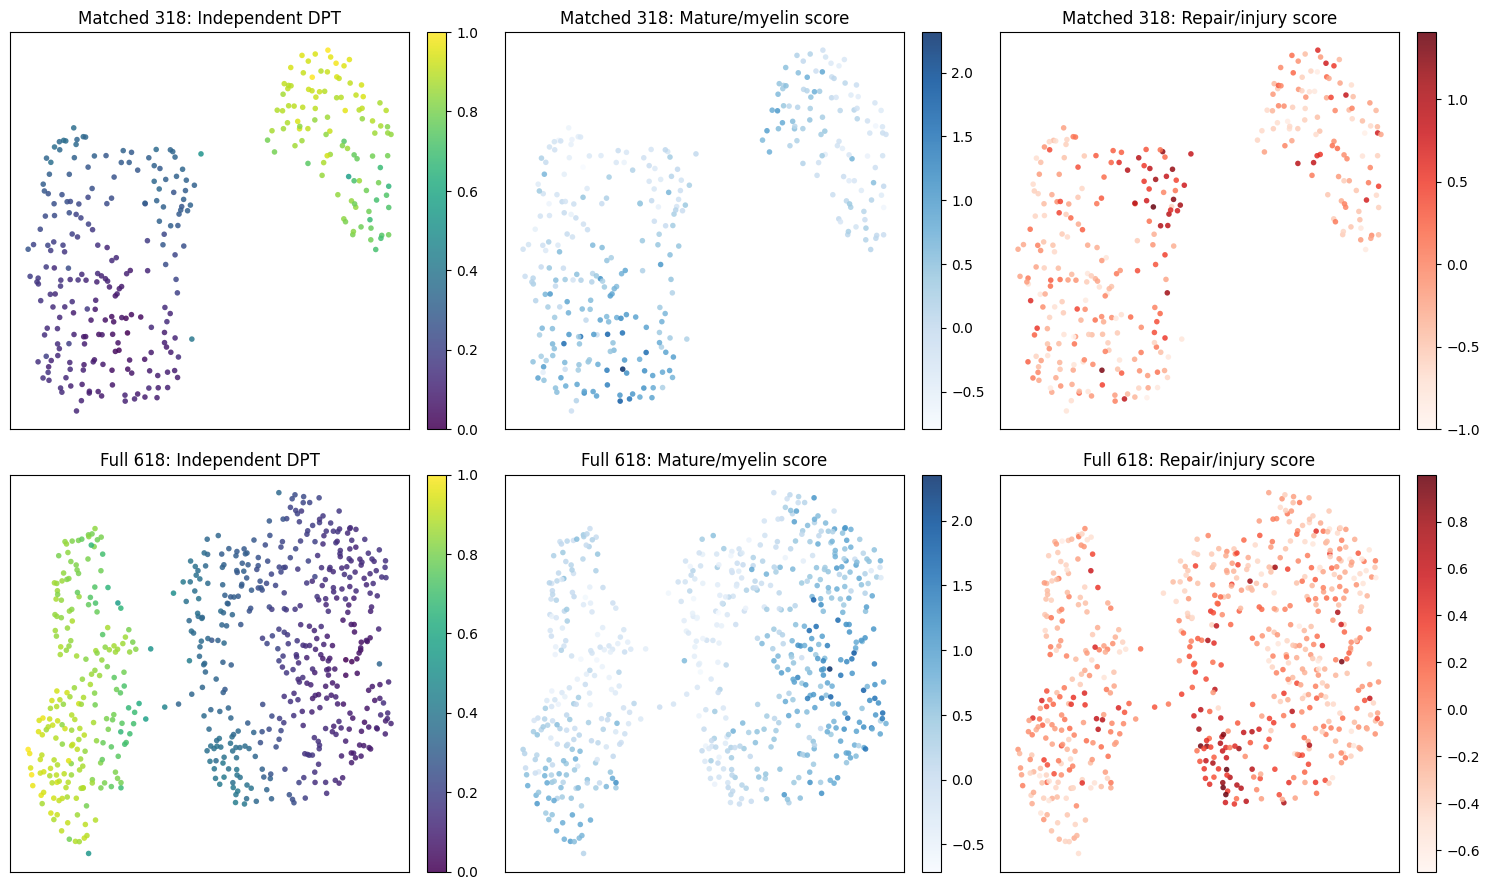


CELL 5 COMPLETE — PASS
Independent count-derived graph: YES
Independent DPT constructed: YES

CytoTRACE used: NO
Original graph used: NO
Original fate probabilities used: NO
Original fork labels used: NO
Unverified experimental-time mapping used: NO

Primary cohort:
  318 matched Schwann cells

Sensitivity cohort:
  618 total Schwann cells

Saved:
/content/drive/MyDrive/CNS_PNS_additional_validation/checkpoints/cell05_pns_matched318_independent_manifold.h5ad
/content/drive/MyDrive/CNS_PNS_additional_validation/checkpoints/cell05_pns_full618_independent_manifold.h5ad
/content/drive/MyDrive/CNS_PNS_additional_validation/tables/cell05_independent_manifold_summary.csv
/content/drive/MyDrive/CNS_PNS_additional_validation/figures/cell05_independent_pns_manifold.png

NEXT:
Cell 6 will use this independent pseudotime to construct a new CellRank PseudotimeKernel and ask whether a probability-defined intermediate emerges without CytoTRACE.


In [5]:
# ============================================================
# CELL 5 — INDEPENDENT PNS MANIFOLD + DPT
# ============================================================
#
# PRIMARY PURPOSE
# Reconstruct PNS Schwann-cell geometry from RAW COUNTS without:
#   - CytoTRACE
#   - original CellRank probabilities
#   - original graph
#   - original entropy
#   - original fork assignments
#
# Two analyses:
#   PRIMARY: 318 cells overlapping original 15k discovery set
#   SENSITIVITY: all 618 saved Schwann cells
#
# Direction is anchored independently using a prespecified
# mature/myelinating Schwann-cell transcriptional program.
#
# This is NOT treated as experimental temporal ground truth.
# ============================================================

!pip -q install "scanpy>=1.11,<1.12"

import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.csgraph as csgraph
import matplotlib.pyplot as plt
import hashlib
import json
import importlib.metadata

from pathlib import Path
from datetime import datetime, timezone


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

np.random.seed(MASTER_SEED)

print("=" * 78)
print("CELL 5 — INDEPENDENT PNS MANIFOLD")
print("=" * 78)

print("Scanpy:", importlib.metadata.version("scanpy"))
print("AnnData:", importlib.metadata.version("anndata"))
print("Seed:", MASTER_SEED)


# ============================================================
# 2. LOAD SOURCE OBJECT
# ============================================================

SOURCE = Path(
    "/content/drive/MyDrive/"
    "pns_regeneration_compartment_cellrank.h5ad"
)

source = ad.read_h5ad(SOURCE)

assert source.n_obs == 618
assert "counts" in source.layers
assert source.obs_names.is_unique
assert source.var_names.is_unique

print(
    f"\nSource: {source.n_obs:,} cells × "
    f"{source.n_vars:,} genes"
)


# ============================================================
# 3. LOAD LOCKED COHORT MANIFEST FROM CELL 4
# ============================================================

manifest = pd.read_csv(
    PATHS["tables"] /
    "cell04_pns_validation_cohort_manifest.csv"
)

manifest = manifest.set_index("cell_id")

source_ids = source.obs_names.astype(str)

matched_ids = [
    x for x in source_ids
    if (
        x in manifest.index
        and bool(
            manifest.loc[
                x,
                "primary_matched_cohort"
            ]
        )
    )
]

assert len(matched_ids) == 318
assert len(source_ids) == 618

print(f"Primary matched cohort: {len(matched_ids)}")
print(f"Full sensitivity cohort: {len(source_ids)}")


# ============================================================
# 4. LOCK BIOLOGICAL ANCHOR PROGRAMS
# ============================================================
#
# These genes are used ONLY to orient the independently
# reconstructed expression manifold.
#
# They are NOT used:
#   - to select HVGs
#   - to construct PCA
#   - to construct neighbors
#   - to define the original fork
#
# Mature/myelinating program provides the DPT ROOT direction.
# Repair program is retained as an external directional check.
# ============================================================

MATURE_PROGRAM = [
    "Mpz",
    "Mbp",
    "Pmp22",
    "Egr2",
    "Prx",
    "Mag",
    "Mal",
    "Ndrg1",
]

REPAIR_PROGRAM = [
    "Jun",
    "Ngfr",
    "Sox2",
    "Shh",
    "Gdnf",
    "Bdnf",
]


available_genes = set(source.var_names.astype(str))

mature_present = [
    g for g in MATURE_PROGRAM
    if g in available_genes
]

repair_present = [
    g for g in REPAIR_PROGRAM
    if g in available_genes
]


print("\nPrespecified anchor genes")

print(
    f"Mature/myelinating: "
    f"{len(mature_present)}/{len(MATURE_PROGRAM)}"
)
print(mature_present)

print(
    f"\nRepair/injury: "
    f"{len(repair_present)}/{len(REPAIR_PROGRAM)}"
)
print(repair_present)


if len(mature_present) < 4:
    raise RuntimeError(
        "Too few prespecified mature Schwann markers "
        "are present to define an independent root."
    )

if len(repair_present) < 3:
    print(
        "\nWARNING: fewer than 3 repair markers present. "
        "Repair score will not be used as strong validation."
    )


# ============================================================
# 5. BUILD CLEAN OBJECT FROM COUNTS ONLY
# ============================================================

def build_clean_cohort(cell_ids, cohort_name):

    idx = source.obs_names.astype(str).isin(cell_ids)

    counts = source.layers["counts"][idx, :].copy()

    # Only retain provenance/QC metadata.
    # No CytoTRACE/CellRank/fate fields are copied.

    original_obs = source.obs.loc[idx]

    clean_obs = pd.DataFrame(
        index=original_obs.index.copy()
    )

    # Sample identifier retained for diagnostics only.
    clean_obs["orig.ident"] = (
        original_obs["orig.ident"]
        .astype(str)
        .values
    )

    # Cell-cycle phase retained for diagnostics only.
    clean_obs["Phase"] = (
        original_obs["Phase"]
        .astype(str)
        .values
    )

    clean = ad.AnnData(
        X=counts,
        obs=clean_obs,
        var=pd.DataFrame(
            index=source.var_names.copy()
        ),
    )

    clean.layers["counts"] = counts.copy()

    clean.uns["cohort_name"] = cohort_name

    return clean


matched = build_clean_cohort(
    matched_ids,
    "matched_318"
)

full = build_clean_cohort(
    list(source_ids),
    "full_618"
)


# ============================================================
# 6. INDEPENDENT MANIFOLD FUNCTION
# ============================================================

def construct_manifold(adata, cohort_name):

    print("\n" + "=" * 78)
    print(f"BUILDING: {cohort_name}")
    print("=" * 78)

    # --------------------------------------------------------
    # A. Gene filtering
    # --------------------------------------------------------

    sc.pp.filter_genes(
        adata,
        min_cells=3
    )

    print(
        f"Genes after >=3-cell filter: "
        f"{adata.n_vars:,}"
    )

    # --------------------------------------------------------
    # B. Normalize directly from counts
    # --------------------------------------------------------

    sc.pp.normalize_total(
        adata,
        target_sum=1e4
    )

    sc.pp.log1p(adata)

    # --------------------------------------------------------
    # C. Independent marker scores
    # --------------------------------------------------------

    mature = [
        g for g in mature_present
        if g in adata.var_names
    ]

    repair = [
        g for g in repair_present
        if g in adata.var_names
    ]

    sc.tl.score_genes(
        adata,
        gene_list=mature,
        score_name="mature_anchor_score",
        random_state=MASTER_SEED
    )

    if len(repair) >= 3:

        sc.tl.score_genes(
            adata,
            gene_list=repair,
            score_name="repair_check_score",
            random_state=MASTER_SEED
        )

    # --------------------------------------------------------
    # D. Highly-variable genes
    # --------------------------------------------------------

    n_hvg = min(
        2000,
        adata.n_vars
    )

    sc.pp.highly_variable_genes(
        adata,
        n_top_genes=n_hvg,
        flavor="seurat"
    )

    actual_hvg = int(
        adata.var["highly_variable"].sum()
    )

    print(f"HVGs: {actual_hvg:,}")

    # --------------------------------------------------------
    # E. PCA
    # --------------------------------------------------------

    n_pcs = min(
        30,
        adata.n_obs - 1,
        actual_hvg - 1
    )

    sc.pp.pca(
        adata,
        n_comps=n_pcs,
        mask_var="highly_variable",
        random_state=MASTER_SEED
    )

    # --------------------------------------------------------
    # F. Completely NEW neighbor graph
    # --------------------------------------------------------

    n_neighbors = min(
        15,
        adata.n_obs - 1
    )

    sc.pp.neighbors(
        adata,
        n_neighbors=n_neighbors,
        n_pcs=n_pcs,
        random_state=MASTER_SEED
    )

    # --------------------------------------------------------
    # G. Connectivity audit
    # --------------------------------------------------------

    graph = adata.obsp["connectivities"]

    n_components, component_labels = (
        csgraph.connected_components(
            graph,
            directed=False
        )
    )

    adata.obs[
        "independent_graph_component"
    ] = component_labels.astype(str)

    print(
        f"Graph connected components: "
        f"{n_components}"
    )

    component_counts = (
        pd.Series(component_labels)
        .value_counts()
        .sort_values(ascending=False)
    )

    print(
        "Component sizes:",
        component_counts.to_dict()
    )

    # --------------------------------------------------------
    # H. UMAP only for visualization
    # --------------------------------------------------------

    sc.tl.umap(
        adata,
        random_state=MASTER_SEED
    )

    # --------------------------------------------------------
    # I. Diffusion map
    # --------------------------------------------------------

    sc.tl.diffmap(
        adata,
        n_comps=min(
            15,
            adata.n_obs - 1
        ),
        random_state=MASTER_SEED
    )

    # --------------------------------------------------------
    # J. Choose root robustly
    #
    # Instead of taking the single highest marker-scoring cell:
    #
    #   1. take top 10% mature-score cells
    #   2. compute their PCA centroid
    #   3. choose the top-decile cell closest to centroid
    #
    # This reduces sensitivity to a single extreme-expression cell.
    # --------------------------------------------------------

    score = (
        adata.obs["mature_anchor_score"]
        .to_numpy()
    )

    threshold = np.quantile(
        score,
        0.90
    )

    candidates = np.where(
        score >= threshold
    )[0]

    X_pca = np.asarray(
        adata.obsm["X_pca"]
    )

    centroid = (
        X_pca[candidates]
        .mean(axis=0)
    )

    distances = np.linalg.norm(
        X_pca[candidates] - centroid,
        axis=1
    )

    root_idx = int(
        candidates[
            np.argmin(distances)
        ]
    )

    root_cell = str(
        adata.obs_names[root_idx]
    )

    adata.uns["iroot"] = root_idx

    adata.uns[
        "independent_root_cell"
    ] = root_cell

    adata.uns[
        "root_definition"
    ] = (
        "PCA medoid-like cell among top 10% "
        "mature/myelinating Schwann score"
    )

    print(f"Independent root: {root_cell}")

    print(
        "Root mature score:",
        float(
            adata.obs.iloc[
                root_idx
            ]["mature_anchor_score"]
        )
    )

    # --------------------------------------------------------
    # K. DPT
    # --------------------------------------------------------

    sc.tl.dpt(
        adata,
        n_dcs=min(
            10,
            adata.obsm["X_diffmap"].shape[1]
        )
    )

    adata.obs.rename(
        columns={
            "dpt_pseudotime":
                "independent_dpt"
        },
        inplace=True
    )

    dpt = (
        adata.obs["independent_dpt"]
        .astype(float)
    )

    finite_dpt = np.isfinite(dpt)

    print(
        f"Finite DPT: "
        f"{finite_dpt.sum():,}/"
        f"{adata.n_obs:,}"
    )

    print(
        f"DPT range: "
        f"{dpt[finite_dpt].min():.4f} – "
        f"{dpt[finite_dpt].max():.4f}"
    )

    # --------------------------------------------------------
    # L. Directional sanity checks
    # --------------------------------------------------------

    mature_corr = (
        adata.obs[
            ["independent_dpt",
             "mature_anchor_score"]
        ]
        .corr(
            method="spearman"
        )
        .iloc[0, 1]
    )

    print(
        f"Spearman(DPT, mature score): "
        f"{mature_corr:.4f}"
    )

    if "repair_check_score" in adata.obs:

        repair_corr = (
            adata.obs[
                ["independent_dpt",
                 "repair_check_score"]
            ]
            .corr(
                method="spearman"
            )
            .iloc[0, 1]
        )

        print(
            f"Spearman(DPT, repair score): "
            f"{repair_corr:.4f}"
        )

    else:
        repair_corr = np.nan

    # --------------------------------------------------------
    # M. Sample distribution audit
    # --------------------------------------------------------

    adata.obs[
        "dpt_quartile"
    ] = pd.qcut(
        adata.obs[
            "independent_dpt"
        ],
        4,
        labels=[
            "Q1",
            "Q2",
            "Q3",
            "Q4"
        ],
        duplicates="drop"
    )

    sample_table = pd.crosstab(
        adata.obs["orig.ident"],
        adata.obs["dpt_quartile"]
    )

    print("\nSample distribution across DPT:")
    display(sample_table)

    # --------------------------------------------------------
    # N. Store audit information
    # --------------------------------------------------------

    adata.uns[
        "independent_manifold_parameters"
    ] = {
        "counts_source":
            "original counts layer",

        "normalization":
            "normalize_total_10000_log1p",

        "hvg":
            "seurat_top_2000",

        "n_hvg":
            actual_hvg,

        "n_pcs":
            n_pcs,

        "n_neighbors":
            n_neighbors,

        "master_seed":
            MASTER_SEED,

        "cytotrace_used":
            False,

        "original_graph_used":
            False,

        "original_fate_probabilities_used":
            False,

        "original_fork_labels_used":
            False,

        "experimental_time_assumed":
            False,

        "root_program":
            mature,

        "repair_check_program":
            repair,
    }

    return {
        "cohort":
            cohort_name,

        "n_cells":
            int(adata.n_obs),

        "n_genes":
            int(adata.n_vars),

        "n_hvg":
            actual_hvg,

        "n_graph_components":
            int(n_components),

        "root_cell":
            root_cell,

        "mature_dpt_spearman":
            float(mature_corr),

        "repair_dpt_spearman":
            (
                float(repair_corr)
                if np.isfinite(repair_corr)
                else None
            )
    }


# ============================================================
# 7. RUN PRIMARY + SENSITIVITY MANIFOLDS
# ============================================================

matched_result = construct_manifold(
    matched,
    "MATCHED_318_PRIMARY"
)

full_result = construct_manifold(
    full,
    "FULL_618_SENSITIVITY"
)


# ============================================================
# 8. SAVE NEW OBJECTS — NEVER OVERWRITE ORIGINALS
# ============================================================

matched_path = (
    PATHS["checkpoints"] /
    "cell05_pns_matched318_independent_manifold.h5ad"
)

full_path = (
    PATHS["checkpoints"] /
    "cell05_pns_full618_independent_manifold.h5ad"
)

matched.write_h5ad(
    matched_path,
    compression="gzip"
)

full.write_h5ad(
    full_path,
    compression="gzip"
)


# ============================================================
# 9. SAVE SUMMARY
# ============================================================

summary = pd.DataFrame([
    matched_result,
    full_result
])

summary_path = (
    PATHS["tables"] /
    "cell05_independent_manifold_summary.csv"
)

summary.to_csv(
    summary_path,
    index=False
)

print("\n" + "=" * 78)
print("INDEPENDENT MANIFOLD SUMMARY")
print("=" * 78)

display(summary)


# ============================================================
# 10. FIGURE
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

for row, (adata, name) in enumerate([
    (matched, "Matched 318"),
    (full, "Full 618")
]):

    xy = adata.obsm["X_umap"]

    plots = [
        (
            adata.obs[
                "independent_dpt"
            ].astype(float),
            "Independent DPT",
            "viridis"
        ),
        (
            adata.obs[
                "mature_anchor_score"
            ].astype(float),
            "Mature/myelin score",
            "Blues"
        ),
        (
            adata.obs.get(
                "repair_check_score",
                pd.Series(
                    np.zeros(adata.n_obs),
                    index=adata.obs_names
                )
            ).astype(float),
            "Repair/injury score",
            "Reds"
        )
    ]

    for col, (
        values,
        title,
        cmap
    ) in enumerate(plots):

        ax = axes[row, col]

        s = ax.scatter(
            xy[:, 0],
            xy[:, 1],
            c=values,
            cmap=cmap,
            s=16,
            alpha=0.85,
            linewidths=0
        )

        ax.set_title(
            f"{name}: {title}"
        )

        ax.set_xticks([])
        ax.set_yticks([])

        plt.colorbar(
            s,
            ax=ax,
            fraction=0.046,
            pad=0.04
        )

plt.tight_layout()

figure_path = (
    PATHS["figures"] /
    "cell05_independent_pns_manifold.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 11. STATUS
# ============================================================

status = {
    "cell": 5,
    "name":
        "Independent PNS expression manifold and pseudotime",

    "status":
        "PASS",

    "timestamp_utc":
        datetime.now(timezone.utc).isoformat(),

    "primary_cells":
        int(matched.n_obs),

    "sensitivity_cells":
        int(full.n_obs),

    "cytotrace_used_for_graph":
        False,

    "cytotrace_used_for_direction":
        False,

    "original_graph_used":
        False,

    "original_fate_probabilities_used":
        False,

    "original_fork_labels_used":
        False,

    "experimental_time_mapping_assumed":
        False,

    "direction_anchor":
        "prespecified mature/myelinating Schwann program"
}

(
    PATHS["logs"] /
    "cell_05_status.json"
).write_text(
    json.dumps(
        status,
        indent=2
    )
)


# ============================================================
# 12. FINAL
# ============================================================

print("\n" + "=" * 78)
print("CELL 5 COMPLETE — PASS")
print("=" * 78)

print("Independent count-derived graph: YES")
print("Independent DPT constructed: YES")

print("\nCytoTRACE used: NO")
print("Original graph used: NO")
print("Original fate probabilities used: NO")
print("Original fork labels used: NO")
print("Unverified experimental-time mapping used: NO")

print("\nPrimary cohort:")
print(f"  {matched.n_obs} matched Schwann cells")

print("\nSensitivity cohort:")
print(f"  {full.n_obs} total Schwann cells")

print("\nSaved:")
print(matched_path)
print(full_path)
print(summary_path)
print(figure_path)

print("\nNEXT:")
print(
    "Cell 6 will use this independent pseudotime to construct "
    "a new CellRank PseudotimeKernel and ask whether a "
    "probability-defined intermediate emerges without CytoTRACE."
)

print("=" * 78)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.0/245.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.6/133.6 kB 7.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
flask 3.1.3 requires jinja2>=3.1.2, but you have jinja2 3.0.3 which is incompatible.
sphinx 8.2.3 requires Jinja2>=3.1, but you have jinja2 3.0.3 which is incompatible.
CELL 6 — FINAL INDEPENDENT PNS VALIDATION
CellRank: 2.3.2
Scanpy: 1.11.5
Seed: 20260808

Matched: (318, 12321)
Full: (618, 13423)

MATCHED_318_PRIMARY — 4 MACROSTATES
INFO     Computing transition matrix based on pseudotime                                                           


  0%|          | 0/318 [00:00<?, ?cell/s]

INFO         Finish (0.21s)                                                                                        
WARNING  Unable to import `petsc4py` or `slepc4py`. Using `method='brandts'`                                       
WARNING  For `method='brandts'`, dense matrix is required. Densifying                                              
INFO     Computing Schur decomposition                                                                             
INFO     When computing macrostates, choose a number of states NOT in ``                                           
INFO     Adding `adata.uns['eigendecomposition_fwd']`                                                              
                `.schur_vectors`                                                                                   
                `.schur_matrix`                                                                                    
                `.eigendecomposition`                                   

  0%|          | 0/2 [00:00<?, ?/s]

INFO     Adding `adata.obsm['lineages_fwd']`                                                                       
                `.fate_probabilities`                                                                              
             Finish (0.13s)                                                                                        
Terminal states: ['1', '3']
40–60 intermediate: 62/318 (19.50%)
45–55 core: 35/318 (11.01%)
Median entropy: 0.7452

FULL_618_REPLICATION — 4 MACROSTATES
INFO     Computing transition matrix based on pseudotime                                                           


...

INFO         Finish (0.29s)                                                                                        
WARNING  Unable to import `petsc4py` or `slepc4py`. Using `method='brandts'`                                       
WARNING  For `method='brandts'`, dense matrix is required. Densifying                                              
INFO     Computing Schur decomposition                                                                             
WARNING  Using `20` components would split a block of complex conjugate eigenvalues. Using `n_components=21`       
INFO     When computing macrostates, choose a number of states NOT in ``                                           
INFO     Adding `adata.uns['eigendecomposition_fwd']`                                                              
                `.schur_vectors`                                                                                   
                `.schur_matrix`                                         

  0%|          | 0/2 [00:00<?, ?/s]

INFO     Adding `adata.obsm['lineages_fwd']`                                                                       
                `.fate_probabilities`                                                                              
             Finish (0.13s)                                                                                        
Terminal states: ['4', '2']
40–60 intermediate: 221/618 (35.76%)
45–55 core: 139/618 (22.49%)
Median entropy: 0.9083

MACROSTATE SENSITIVITY


,label,n_macrostates,n_cells,terminal_A,terminal_B,n_4060,fraction_4060,n_4555,fraction_4555,median_entropy
3,FULL_618_REPLICATION,3,618,0,2,218,0.352751,140,0.226537,0.907408
1,FULL_618_REPLICATION,4,618,2,3,218,0.352751,140,0.226537,0.907825
5,FULL_618_REPLICATION,5,618,4,2,221,0.357605,139,0.224919,0.908336
2,MATCHED_318_PRIMARY,3,318,0,2,107,0.336478,36,0.113208,0.902468
0,MATCHED_318_PRIMARY,4,318,1,3,62,0.194969,35,0.110063,0.745199
4,MATCHED_318_PRIMARY,5,318,2,1,108,0.339623,36,0.113208,0.893833



SAMPLE-CLUSTER BOOTSTRAP
Matched: {'estimate': 0.1949685534591195, 'ci_low': 0.1282051282051282, 'ci_high': 0.2641509433962264, 'n_sample_groups': 5, 'bootstrap_replicates': 2000}
Full: {'estimate': 0.35275080906148865, 'ci_low': 0.3018867924528302, 'ci_high': 0.4330357142857143, 'n_sample_groups': 5, 'bootstrap_replicates': 2000}

POST-HOC COMPARISON WITH ORIGINAL MODEL
Original 40–60 cells: 38
Independent 40–60 cells: 62
Intersection: 0
Jaccard overlap: 0.0000

Independent entropy vs original entropy:
Spearman rho = -0.1507

Independent entropy vs CytoTRACE plasticity:
Spearman rho = -0.2260

CytoTRACE plasticity:
New intermediate median = 0.016892145809845882
Other cells median       = 0.016328447951897807
Median difference        = 0.0005636978579480756


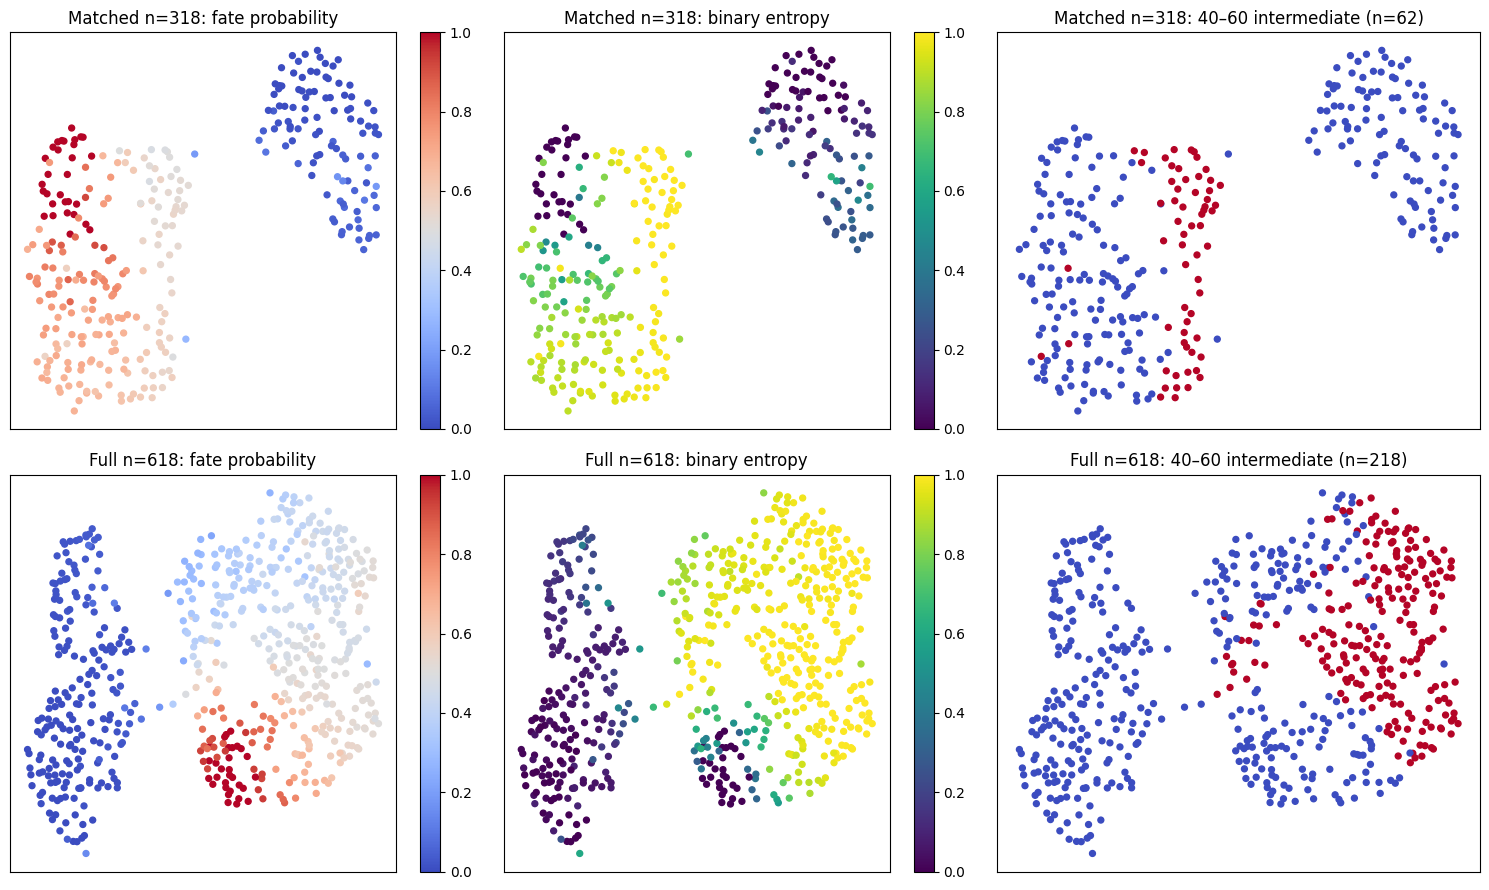


CELL 6 COMPLETE — FINAL VALIDATION

CLASSIFICATION:
INDEPENDENT_INTERMEDIATE_PRESENT_IN_BOTH_COHORTS

PRIMARY — MATCHED 318
40–60 intermediate: 62/318 (19.50%)
Cluster-bootstrap 95% interval: (0.1282051282051282, 0.2641509433962264)
Graph coherence fold: 3.660357200616335
Permutation p: 0.000999000999000999

REPLICATION — FULL 618
40–60 intermediate: 218/618 (35.28%)
Cluster-bootstrap 95% interval: (0.3018867924528302, 0.4330357142857143)
Graph coherence fold: 2.3159947401532492
Permutation p: 0.000999000999000999

COMPARISON WITH ORIGINAL
Old/new 40–60 Jaccard: 0.0
New entropy vs original entropy rho: -0.150711214310268
New entropy vs CytoTRACE rho: -0.2259814883319083

INTERPRETATION GUARDRAILS
CytoTRACE constructed new model: NO
Original graph reused: NO
Original probabilities reused: NO
Graph coherence counted as independent evidence: NO
Repair/regeneration direction claimed from DPT: NO

FINAL OUTPUTS:
/content/drive/MyDrive/CNS_PNS_additional_validation/tables/cell06_final_prima

In [6]:
# ============================================================
# CELL 6 — FINAL INDEPENDENT PNS VALIDATION
# ============================================================
#
# Tests whether probability-defined fate/intermediate geometry
# exists WITHOUT CytoTRACE directing the transition kernel.
#
# PRIMARY:
#   318 matched Schwann cells
#
# REPLICATION:
#   full 618 Schwann cells
#
# Includes:
#   - CellRank PseudotimeKernel
#   - GPCCA
#   - 2 independently selected terminal states
#   - binary fate entropy
#   - pre-specified 40–60% intermediate
#   - nested 45–55% core
#   - graph-coherence permutation diagnostic
#   - cluster bootstrap CIs
#   - macrostate-number sensitivity (3/4/5)
#   - threshold sensitivity
#   - comparison to ORIGINAL model only after fitting
#
# IMPORTANT:
# A result is reported regardless of direction.
# ============================================================

%pip -q install "cellrank>=2.0,<3"

import cellrank as cr
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.stats as stats
import matplotlib.pyplot as plt
import importlib.metadata
import json

from pathlib import Path
from datetime import datetime, timezone

np.random.seed(MASTER_SEED)

print("=" * 80)
print("CELL 6 — FINAL INDEPENDENT PNS VALIDATION")
print("=" * 80)

print("CellRank:", importlib.metadata.version("cellrank"))
print("Scanpy:", importlib.metadata.version("scanpy"))
print("Seed:", MASTER_SEED)


# ============================================================
# 1. LOAD CELL-5 OBJECTS
# ============================================================

MATCHED_PATH = (
    PATHS["checkpoints"] /
    "cell05_pns_matched318_independent_manifold.h5ad"
)

FULL_PATH = (
    PATHS["checkpoints"] /
    "cell05_pns_full618_independent_manifold.h5ad"
)

matched = ad.read_h5ad(MATCHED_PATH)
full = ad.read_h5ad(FULL_PATH)

assert matched.n_obs == 318
assert full.n_obs == 618

for A in [matched, full]:
    assert "independent_dpt" in A.obs
    assert "connectivities" in A.obsp

print("\nMatched:", matched.shape)
print("Full:", full.shape)


# ============================================================
# 2. CELLRANK FIT
# ============================================================

def run_cellrank(A, label, n_macrostates=4):

    print("\n" + "=" * 80)
    print(f"{label} — {n_macrostates} MACROSTATES")
    print("=" * 80)

    B = A.copy()

    # --------------------------------------------------------
    # PseudotimeKernel:
    # direction comes ONLY from independent DPT.
    # --------------------------------------------------------

    kernel = cr.kernels.PseudotimeKernel(
        B,
        time_key="independent_dpt"
    )

    kernel.compute_transition_matrix()

    # --------------------------------------------------------
    # GPCCA
    # --------------------------------------------------------

    g = cr.estimators.GPCCA(kernel)

    g.compute_schur()

    g.compute_macrostates(
        n_states=n_macrostates
    )

    # Exactly two terminal states prespecified because the
    # hypothesis concerns a binary probability-defined fork.
    g.predict_terminal_states(
        method="top_n",
        n_states=2
    )

    g.compute_fate_probabilities()

    FP = np.asarray(
        g.fate_probabilities
    )

    names = list(
        map(
            str,
            g.fate_probabilities.names
        )
    )

    if FP.shape[1] != 2:
        raise RuntimeError(
            f"Expected 2 terminal fates, got {FP.shape[1]}"
        )

    # Numerical normalization
    denom = FP.sum(axis=1)

    if np.any(denom <= 0):
        raise RuntimeError(
            "Invalid fate-probability denominator."
        )

    FP = FP / denom[:, None]

    p = FP[:, 0]

    # --------------------------------------------------------
    # Binary entropy
    # --------------------------------------------------------

    eps = np.finfo(float).eps

    pclip = np.clip(
        p,
        eps,
        1 - eps
    )

    entropy = -(
        pclip * np.log2(pclip)
        +
        (1 - pclip)
        * np.log2(1 - pclip)
    )

    # Label-invariant balance score:
    # 1 = perfect 50/50
    # 0 = fully committed
    balance = 1 - np.abs(
        2 * p - 1
    )

    balanced_4060 = (
        (p >= 0.40)
        &
        (p <= 0.60)
    )

    core_4555 = (
        (p >= 0.45)
        &
        (p <= 0.55)
    )

    # Save only plain numeric outputs
    B.obs["independent_fate_A"] = FP[:, 0]
    B.obs["independent_fate_B"] = FP[:, 1]

    B.obs[
        "independent_binary_entropy"
    ] = entropy

    B.obs[
        "independent_balance_score"
    ] = balance

    B.obs[
        "independent_intermediate_4060"
    ] = balanced_4060

    B.obs[
        "independent_core_4555"
    ] = core_4555

    print("Terminal states:", names)

    print(
        f"40–60 intermediate: "
        f"{balanced_4060.sum()}/{B.n_obs} "
        f"({balanced_4060.mean():.2%})"
    )

    print(
        f"45–55 core: "
        f"{core_4555.sum()}/{B.n_obs} "
        f"({core_4555.mean():.2%})"
    )

    print(
        f"Median entropy: "
        f"{np.median(entropy):.4f}"
    )

    return (
        B,
        g,
        {
            "label": label,
            "n_macrostates": n_macrostates,
            "n_cells": int(B.n_obs),
            "terminal_A": names[0],
            "terminal_B": names[1],
            "n_4060": int(
                balanced_4060.sum()
            ),
            "fraction_4060": float(
                balanced_4060.mean()
            ),
            "n_4555": int(
                core_4555.sum()
            ),
            "fraction_4555": float(
                core_4555.mean()
            ),
            "median_entropy": float(
                np.median(entropy)
            ),
        }
    )


# ============================================================
# 3. PRIMARY MODELS
# ============================================================

matched_cr, matched_est, matched_summary = (
    run_cellrank(
        matched,
        "MATCHED_318_PRIMARY",
        n_macrostates=4
    )
)

full_cr, full_est, full_summary = (
    run_cellrank(
        full,
        "FULL_618_REPLICATION",
        n_macrostates=4
    )
)


# ============================================================
# 4. GRAPH-COHERENCE PERMUTATION DIAGNOSTIC
# ============================================================
#
# This is explicitly a DEPENDENT diagnostic because both the
# probabilities and coherence depend on the same graph.
#
# It is NOT counted as independent evidence.
# ============================================================

def graph_coherence_test(
    A,
    mask,
    n_perm=1000,
    seed=MASTER_SEED
):

    mask = np.asarray(mask, dtype=bool)

    n_selected = int(mask.sum())

    if n_selected < 2:
        return {
            "n": n_selected,
            "observed": np.nan,
            "null_mean": np.nan,
            "fold": np.nan,
            "p_perm": np.nan
        }

    G = A.obsp[
        "connectivities"
    ].copy().tocsr()

    # Binary adjacency
    G.data[:] = 1.0
    G.setdiag(0)
    G.eliminate_zeros()

    degree = np.asarray(
        G.sum(axis=1)
    ).ravel()

    def coherence(m):

        m = np.asarray(
            m,
            dtype=float
        )

        selected_neighbors = (
            np.asarray(
                G.dot(m)
            ).ravel()
        )

        frac = np.divide(
            selected_neighbors,
            degree,
            out=np.zeros_like(
                selected_neighbors,
                dtype=float
            ),
            where=degree > 0
        )

        return float(
            frac[mask.astype(bool)].mean()
        )

    observed = coherence(mask)

    rng = np.random.default_rng(seed)

    null = np.zeros(
        n_perm,
        dtype=float
    )

    for i in range(n_perm):

        random_idx = rng.choice(
            A.n_obs,
            size=n_selected,
            replace=False
        )

        random_mask = np.zeros(
            A.n_obs,
            dtype=bool
        )

        random_mask[random_idx] = True

        # calculate coherence among RANDOM cells
        m = random_mask.astype(float)

        selected_neighbors = (
            np.asarray(
                G.dot(m)
            ).ravel()
        )

        frac = np.divide(
            selected_neighbors,
            degree,
            out=np.zeros_like(
                selected_neighbors,
                dtype=float
            ),
            where=degree > 0
        )

        null[i] = (
            frac[random_mask].mean()
        )

    null_mean = float(
        null.mean()
    )

    fold = (
        observed / null_mean
        if null_mean > 0
        else np.nan
    )

    # Correct finite-permutation p-value
    p_perm = (
        np.sum(
            null >= observed
        ) + 1
    ) / (
        n_perm + 1
    )

    return {
        "n": n_selected,
        "observed": observed,
        "null_mean": null_mean,
        "fold": float(fold),
        "p_perm": float(p_perm)
    }


print("\n" + "=" * 80)
print("GRAPH COHERENCE — DEPENDENT DIAGNOSTIC")
print("=" * 80)

matched_coherence = graph_coherence_test(
    matched_cr,
    matched_cr.obs[
        "independent_intermediate_4060"
    ],
    n_perm=1000,
    seed=MASTER_SEED
)

full_coherence = graph_coherence_test(
    full_cr,
    full_cr.obs[
        "independent_intermediate_4060"
    ],
    n_perm=1000,
    seed=MASTER_SEED + 1
)

print(
    "\nMatched:",
    matched_coherence
)

print(
    "\nFull:",
    full_coherence
)


# ============================================================
# 5. THRESHOLD SENSITIVITY
# ============================================================

THRESHOLDS = [
    (0.35, 0.65),
    (0.40, 0.60),
    (0.45, 0.55)
]

threshold_rows = []

for label, A in [
    ("MATCHED_318", matched_cr),
    ("FULL_618", full_cr)
]:

    p = A.obs[
        "independent_fate_A"
    ].to_numpy()

    for lower, upper in THRESHOLDS:

        mask = (
            (p >= lower)
            &
            (p <= upper)
        )

        threshold_rows.append({
            "cohort": label,
            "lower": lower,
            "upper": upper,
            "n": int(mask.sum()),
            "fraction": float(
                mask.mean()
            )
        })

threshold_table = pd.DataFrame(
    threshold_rows
)

print("\n" + "=" * 80)
print("THRESHOLD SENSITIVITY")
print("=" * 80)

display(threshold_table)


# ============================================================
# 6. MACROSTATE-NUMBER SENSITIVITY
# ============================================================
#
# 4 macrostates = locked primary analysis.
# 3 and 5 are sensitivity analyses.
# ============================================================

macro_rows = [
    matched_summary,
    full_summary
]

for n_macro in [3, 5]:

    for A, label in [
        (
            matched,
            "MATCHED_318_PRIMARY"
        ),
        (
            full,
            "FULL_618_REPLICATION"
        )
    ]:

        try:

            _, _, res = run_cellrank(
                A,
                label,
                n_macrostates=n_macro
            )

            macro_rows.append(res)

        except Exception as exc:

            macro_rows.append({
                "label": label,
                "n_macrostates": n_macro,
                "error": repr(exc)
            })

            print(
                f"\nSensitivity failure "
                f"{label}, K={n_macro}: "
                f"{exc}"
            )

macro_table = pd.DataFrame(
    macro_rows
)

print("\n" + "=" * 80)
print("MACROSTATE SENSITIVITY")
print("=" * 80)

display(
    macro_table.sort_values(
        ["label", "n_macrostates"]
    )
)


# ============================================================
# 7. SAMPLE-CLUSTER BOOTSTRAP
# ============================================================
#
# Resample orig.ident groups, not individual cells.
#
# These intervals quantify stability of the DESCRIPTIVE
# intermediate fraction with respect to sample composition.
#
# They are NOT model-refitting confidence intervals.
# ============================================================

def cluster_bootstrap_fraction(
    A,
    n_boot=2000,
    seed=MASTER_SEED
):

    df = pd.DataFrame({
        "sample":
            A.obs["orig.ident"]
            .astype(str)
            .values,

        "balanced":
            A.obs[
                "independent_intermediate_4060"
            ]
            .astype(bool)
            .values
    })

    groups = {
        k: v["balanced"].to_numpy()
        for k, v in df.groupby("sample")
    }

    names = list(groups.keys())

    rng = np.random.default_rng(seed)

    boot = np.zeros(
        n_boot,
        dtype=float
    )

    for i in range(n_boot):

        sampled = rng.choice(
            names,
            size=len(names),
            replace=True
        )

        values = np.concatenate([
            groups[x]
            for x in sampled
        ])

        boot[i] = values.mean()

    return {
        "estimate":
            float(df["balanced"].mean()),

        "ci_low":
            float(
                np.quantile(
                    boot,
                    0.025
                )
            ),

        "ci_high":
            float(
                np.quantile(
                    boot,
                    0.975
                )
            ),

        "n_sample_groups":
            len(names),

        "bootstrap_replicates":
            n_boot
    }


matched_boot = (
    cluster_bootstrap_fraction(
        matched_cr,
        seed=MASTER_SEED
    )
)

full_boot = (
    cluster_bootstrap_fraction(
        full_cr,
        seed=MASTER_SEED + 1
    )
)

print("\n" + "=" * 80)
print("SAMPLE-CLUSTER BOOTSTRAP")
print("=" * 80)

print("Matched:", matched_boot)
print("Full:", full_boot)


# ============================================================
# 8. ONLY NOW LOAD ORIGINAL CYTOTRACE-DIRECTED RESULTS
# ============================================================

print("\n" + "=" * 80)
print("POST-HOC COMPARISON WITH ORIGINAL MODEL")
print("=" * 80)

ORIGINAL = Path(
    "/content/drive/MyDrive/"
    "pns_regenerative_fork_final.h5ad"
)

old = ad.read_h5ad(
    ORIGINAL,
    backed="r"
)

old_obs = old.obs.copy()

# Align original results to NEW matched object.
aligned = old_obs.reindex(
    matched_cr.obs_names
)

assert aligned.index.equals(
    matched_cr.obs_names
)

required_old = [
    "pairwise_regen_probability",
    "pairwise_fate_entropy",
    "cytotrace_plasticity"
]

for col in required_old:
    assert col in aligned.columns, (
        f"Missing original field: {col}"
    )


old_p = pd.to_numeric(
    aligned[
        "pairwise_regen_probability"
    ],
    errors="coerce"
).to_numpy()

old_entropy = pd.to_numeric(
    aligned[
        "pairwise_fate_entropy"
    ],
    errors="coerce"
).to_numpy()

old_ct = pd.to_numeric(
    aligned[
        "cytotrace_plasticity"
    ],
    errors="coerce"
).to_numpy()


new_p = matched_cr.obs[
    "independent_fate_A"
].to_numpy()

new_entropy = matched_cr.obs[
    "independent_binary_entropy"
].to_numpy()

new_balanced = matched_cr.obs[
    "independent_intermediate_4060"
].to_numpy().astype(bool)


# Original 40–60 definition
old_balanced = (
    np.isfinite(old_p)
    &
    (old_p >= 0.40)
    &
    (old_p <= 0.60)
)


# ============================================================
# 9. OVERLAP WITH ORIGINAL BALANCED REGION
# ============================================================

intersection = int(
    np.sum(
        new_balanced
        &
        old_balanced
    )
)

union = int(
    np.sum(
        new_balanced
        |
        old_balanced
    )
)

jaccard = (
    intersection / union
    if union > 0
    else np.nan
)


valid_entropy = (
    np.isfinite(new_entropy)
    &
    np.isfinite(old_entropy)
)

entropy_rho, entropy_p = (
    stats.spearmanr(
        new_entropy[
            valid_entropy
        ],
        old_entropy[
            valid_entropy
        ]
    )
)


valid_ct = (
    np.isfinite(new_entropy)
    &
    np.isfinite(old_ct)
)

ct_rho, ct_p = (
    stats.spearmanr(
        new_entropy[
            valid_ct
        ],
        old_ct[
            valid_ct
        ]
    )
)


print(
    f"Original 40–60 cells: "
    f"{old_balanced.sum()}"
)

print(
    f"Independent 40–60 cells: "
    f"{new_balanced.sum()}"
)

print(
    f"Intersection: {intersection}"
)

print(
    f"Jaccard overlap: "
    f"{jaccard:.4f}"
)

print(
    "\nIndependent entropy vs "
    "original entropy:"
)

print(
    f"Spearman rho = "
    f"{entropy_rho:.4f}"
)

print(
    "\nIndependent entropy vs "
    "CytoTRACE plasticity:"
)

print(
    f"Spearman rho = "
    f"{ct_rho:.4f}"
)


# ============================================================
# 10. CYTOTRACE AS EXTERNAL CHECK
# ============================================================
#
# This association is permissible because CytoTRACE was NOT
# used to build the new graph/kernel/probabilities.
#
# Still descriptive at cell level.
# ============================================================

ct_balanced = old_ct[
    new_balanced
    &
    np.isfinite(old_ct)
]

ct_other = old_ct[
    (~new_balanced)
    &
    np.isfinite(old_ct)
]


if (
    len(ct_balanced) > 0
    and
    len(ct_other) > 0
):

    ct_bal_median = float(
        np.median(ct_balanced)
    )

    ct_other_median = float(
        np.median(ct_other)
    )

    ct_delta = (
        ct_bal_median
        -
        ct_other_median
    )

else:

    ct_bal_median = np.nan
    ct_other_median = np.nan
    ct_delta = np.nan


print(
    "\nCytoTRACE plasticity:"
)

print(
    "New intermediate median =",
    ct_bal_median
)

print(
    "Other cells median       =",
    ct_other_median
)

print(
    "Median difference        =",
    ct_delta
)


# ============================================================
# 11. SAVE FINAL TABLES
# ============================================================

primary_table = pd.DataFrame([
    {
        **matched_summary,
        "coherence_observed":
            matched_coherence["observed"],
        "coherence_null":
            matched_coherence["null_mean"],
        "coherence_fold":
            matched_coherence["fold"],
        "coherence_p_perm":
            matched_coherence["p_perm"],
        "bootstrap_ci_low":
            matched_boot["ci_low"],
        "bootstrap_ci_high":
            matched_boot["ci_high"],
    },
    {
        **full_summary,
        "coherence_observed":
            full_coherence["observed"],
        "coherence_null":
            full_coherence["null_mean"],
        "coherence_fold":
            full_coherence["fold"],
        "coherence_p_perm":
            full_coherence["p_perm"],
        "bootstrap_ci_low":
            full_boot["ci_low"],
        "bootstrap_ci_high":
            full_boot["ci_high"],
    }
])


comparison_table = pd.DataFrame([{
    "matched_cells":
        matched_cr.n_obs,

    "old_4060_n":
        int(old_balanced.sum()),

    "new_4060_n":
        int(new_balanced.sum()),

    "intersection_n":
        intersection,

    "jaccard":
        jaccard,

    "new_vs_old_entropy_spearman":
        entropy_rho,

    "new_entropy_vs_cytotrace_spearman":
        ct_rho,

    "cytotrace_median_intermediate":
        ct_bal_median,

    "cytotrace_median_other":
        ct_other_median,

    "cytotrace_median_difference":
        ct_delta,
}])


primary_path = (
    PATHS["tables"] /
    "cell06_final_primary_results.csv"
)

threshold_path = (
    PATHS["tables"] /
    "cell06_threshold_sensitivity.csv"
)

macro_path = (
    PATHS["tables"] /
    "cell06_macrostate_sensitivity.csv"
)

comparison_path = (
    PATHS["tables"] /
    "cell06_original_vs_independent.csv"
)

primary_table.to_csv(
    primary_path,
    index=False
)

threshold_table.to_csv(
    threshold_path,
    index=False
)

macro_table.to_csv(
    macro_path,
    index=False
)

comparison_table.to_csv(
    comparison_path,
    index=False
)


# ============================================================
# 12. FINAL FIGURE
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

for row, (A, name) in enumerate([
    (
        matched_cr,
        "Matched n=318"
    ),
    (
        full_cr,
        "Full n=618"
    )
]):

    xy = A.obsm["X_umap"]

    # Fate probability
    s0 = axes[row, 0].scatter(
        xy[:, 0],
        xy[:, 1],
        c=A.obs[
            "independent_fate_A"
        ],
        cmap="coolwarm",
        vmin=0,
        vmax=1,
        s=18
    )

    axes[row, 0].set_title(
        f"{name}: fate probability"
    )

    plt.colorbar(
        s0,
        ax=axes[row, 0]
    )

    # Entropy
    s1 = axes[row, 1].scatter(
        xy[:, 0],
        xy[:, 1],
        c=A.obs[
            "independent_binary_entropy"
        ],
        cmap="viridis",
        vmin=0,
        vmax=1,
        s=18
    )

    axes[row, 1].set_title(
        f"{name}: binary entropy"
    )

    plt.colorbar(
        s1,
        ax=axes[row, 1]
    )

    # Balanced state
    balanced = A.obs[
        "independent_intermediate_4060"
    ].astype(int)

    axes[row, 2].scatter(
        xy[:, 0],
        xy[:, 1],
        c=balanced,
        cmap="coolwarm",
        vmin=0,
        vmax=1,
        s=18
    )

    axes[row, 2].set_title(
        f"{name}: 40–60 intermediate "
        f"(n={balanced.sum()})"
    )

    for col in range(3):

        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

plt.tight_layout()

figure_path = (
    PATHS["figures"] /
    "cell06_final_independent_validation.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 13. SAVE FINAL INDEPENDENT OBJECTS
# ============================================================

matched_final_path = (
    PATHS["checkpoints"] /
    "cell06_matched318_final_independent.h5ad"
)

full_final_path = (
    PATHS["checkpoints"] /
    "cell06_full618_final_independent.h5ad"
)

matched_cr.write_h5ad(
    matched_final_path,
    compression="gzip"
)

full_cr.write_h5ad(
    full_final_path,
    compression="gzip"
)


# ============================================================
# 14. INTERPRETATION CLASSIFICATION
# ============================================================

m_n = int(
    matched_cr.obs[
        "independent_intermediate_4060"
    ].sum()
)

f_n = int(
    full_cr.obs[
        "independent_intermediate_4060"
    ].sum()
)

if m_n > 0 and f_n > 0:

    interpretation = (
        "INDEPENDENT_INTERMEDIATE_PRESENT_IN_BOTH_COHORTS"
    )

elif m_n > 0 or f_n > 0:

    interpretation = (
        "PARTIAL_OR_COHORT_DEPENDENT_SUPPORT"
    )

else:

    interpretation = (
        "NO_INDEPENDENT_40_60_INTERMEDIATE"
    )


# ============================================================
# 15. FINAL MACHINE-READABLE SUMMARY
# ============================================================

final_summary = {

    "timestamp_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "classification":
        interpretation,

    "matched_n":
        int(matched_cr.n_obs),

    "matched_intermediate_n":
        m_n,

    "full_n":
        int(full_cr.n_obs),

    "full_intermediate_n":
        f_n,

    "cytotrace_used_to_construct_model":
        False,

    "original_graph_used":
        False,

    "original_fate_probabilities_used":
        False,

    "original_results_accessed_before_new_fit":
        False,

    "graph_coherence_is_independent_evidence":
        False,

    "experimental_time_recovered":
        False,

    "repair_axis_supported_by_cell5":
        False,

    "reason_repair_axis_not_claimed":
        (
            "Independent DPT showed near-zero "
            "Spearman association with the "
            "prespecified repair-marker program."
        ),

    "old_new_intermediate_jaccard":
        (
            float(jaccard)
            if np.isfinite(jaccard)
            else None
        ),

    "new_entropy_vs_cytotrace_rho":
        (
            float(ct_rho)
            if np.isfinite(ct_rho)
            else None
        )
}


summary_json = (
    PATHS["exports"] /
    "FINAL_VALIDATION_SUMMARY.json"
)

summary_json.write_text(
    json.dumps(
        final_summary,
        indent=2
    )
)


# ============================================================
# 16. CLOSE ORIGINAL
# ============================================================

old.file.close()


# ============================================================
# 17. FINAL OUTPUT
# ============================================================

print("\n" + "=" * 80)
print("CELL 6 COMPLETE — FINAL VALIDATION")
print("=" * 80)

print("\nCLASSIFICATION:")
print(interpretation)

print("\nPRIMARY — MATCHED 318")
print(
    f"40–60 intermediate: "
    f"{m_n}/318 "
    f"({m_n/318:.2%})"
)

print(
    "Cluster-bootstrap 95% interval:",
    (
        matched_boot["ci_low"],
        matched_boot["ci_high"]
    )
)

print(
    "Graph coherence fold:",
    matched_coherence["fold"]
)

print(
    "Permutation p:",
    matched_coherence["p_perm"]
)


print("\nREPLICATION — FULL 618")
print(
    f"40–60 intermediate: "
    f"{f_n}/618 "
    f"({f_n/618:.2%})"
)

print(
    "Cluster-bootstrap 95% interval:",
    (
        full_boot["ci_low"],
        full_boot["ci_high"]
    )
)

print(
    "Graph coherence fold:",
    full_coherence["fold"]
)

print(
    "Permutation p:",
    full_coherence["p_perm"]
)


print("\nCOMPARISON WITH ORIGINAL")
print(
    "Old/new 40–60 Jaccard:",
    jaccard
)

print(
    "New entropy vs original entropy rho:",
    entropy_rho
)

print(
    "New entropy vs CytoTRACE rho:",
    ct_rho
)


print("\nINTERPRETATION GUARDRAILS")
print("CytoTRACE constructed new model: NO")
print("Original graph reused: NO")
print("Original probabilities reused: NO")
print(
    "Graph coherence counted as "
    "independent evidence: NO"
)
print(
    "Repair/regeneration direction "
    "claimed from DPT: NO"
)

print("\nFINAL OUTPUTS:")
print(primary_path)
print(threshold_path)
print(macro_path)
print(comparison_path)
print(figure_path)
print(summary_json)

print("\n" + "=" * 80)